In [4]:
import pandas as pd
from rapidfuzz import process, fuzz
import unidecode
import math
from statsbombpy import sb
from datetime import datetime, date, timedelta
import soccerdata as sd
import numpy as np
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score, log_loss, brier_score_loss, mean_absolute_error, accuracy_score
from selenium import webdriver
from IPython.display import clear_output
import shap
import locale
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.firefox.options import Options
import json
from datafc import search_data, seasons_data, standings_data, team_data, squad_data, match_data, shots_data, lineups_data, player_data
import cloudscraper
from bs4 import BeautifulSoup
import undetected_chromedriver as uc
import time
import requests

[15/07/2026 12:11:25] INFO     No custom team name replacements found. You can configure these in     ]8;id=593747;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=932007;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_config.py#92\92]8;;\
                               C:\Users\andre\soccerdata\config\teamname_replacements.json.                        

                      INFO     No custom league dict found. You can configure additional leagues in  ]8;id=234459;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=303413;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_config.py#190\190]8;;\
                               C:\Users\andre\soccerdata\config\league_dict.json.                                  

In [5]:
def getSession():
    driver = uc.Chrome(headless=False)  # inizia con headless=False per debug, poi prova True
    driver.get("https://sofifa.com")

    # Aspetta finché cf_clearance non compare tra i cookie (con timeout)
    max_wait = 30  # secondi
    elapsed = 0
    cf_clearance_found = False

    while elapsed < max_wait:
        cookies = driver.get_cookies()
        if any(c['name'] == 'cf_clearance' for c in cookies):
            cf_clearance_found = True
            break
        time.sleep(1)
        elapsed += 1

    if not cf_clearance_found:
        print("Cloudflare non superato in tempo, controlla screenshot")
        driver.save_screenshot("debug.png")
    else:
        print(f"cf_clearance ottenuto dopo {elapsed}s")

    cookies = driver.get_cookies()
    user_agent = driver.execute_script("return navigator.userAgent")


    session = requests.Session()
    for c in cookies:
        session.cookies.set(c['name'], c['value'])
    session.headers.update({"User-Agent": user_agent})
    driver.quit()
    return session

# resp = session.get("https://sofifa.com/player/268511/walid-cheddira/240050/")
# resp.text

In [6]:
def getSchedule(leagueId, seasonId, round, driver):
    base_url = "https://www.sofascore.com/api/v1/unique-tournament/"
    url = base_url + str(leagueId) + "/season/" + str(seasonId) + "/events/round/" + str(round)
    # print(url)
    data = driver.execute_async_script("""
    const url = arguments[0];
    const callback = arguments[arguments.length - 1];

    fetch(url)
      .then(r => r.json())
      .then(data => callback(data));
    """, url)
    events = data['events']

    rounds = []
    dates = []
    homeTeams = []
    awayTeams = []
    homeScores = []
    awayScores = []
    matchIds = []
    urls = []
    timestamps = []

    for event in events:
        homeTeam = event['homeTeam']['name']
        awayTeam = event['awayTeam']['name']
        if not event["homeScore"] or not event["awayScore"]:
            continue
        homeScore = event['homeScore']['current']
        awayScore = event['awayScore']['current']
        matchId = event['id']
        matchTime = event['startTimestamp']
        matchDate = datetime.fromtimestamp(matchTime)
        matchDate = matchDate.strftime(("%d/%m/%Y"))
        url = "https://www.sofascore.com/api/v1/event/" + str(matchId) + "/shotmap"
        # print(event['homeTeam']['name'], event['awayTeam']['name'], event['homeScore']['current'], event['awayScore']['current'], event['id'])
        rounds.append(round)
        homeTeams.append(homeTeam)
        awayTeams.append(awayTeam)
        homeScores.append(homeScore)
        awayScores.append(awayScore)
        matchIds.append(matchId)
        urls.append(url)
        dates.append(matchDate)
        timestamps.append(matchTime)

    
    df = pd.DataFrame()
    df['round'] = rounds
    df['date'] = dates
    df['homeTeam'] = homeTeams
    df['awayTeam'] = awayTeams
    df['homeScore'] = homeScores
    df['awayScore'] = awayScores
    df['matchId'] = matchIds
    df['url'] = urls
    df['timestamp'] = timestamps
    return df

In [7]:
def getShotmap(matchId, driver, homeTeam, awayTeam):
    # collects the base shotmap from SofaScore

    base_url = "https://www.sofascore.com/api/v1/event/"

    url = base_url + str(matchId) + "/shotmap"

    data = driver.execute_async_script("""
    const url = arguments[0];
    const callback = arguments[arguments.length - 1];

    fetch(url)
      .then(r => r.json())
      .then(data => callback(data));
    """, url)
    shotmap = data['shotmap']
    # print("getShotmap Original:", shotmap[0])
    
    # creates a DataFrame from the SofaScore shotmap with the most useful features

    players = []
    homes = []
    situations = []
    bodyParts = []
    minutes = []
    teams = []
    x = []
    y = []
    goals = []
    xgs = []
    for shot in shotmap:
        if 'goalType' not in shot or shot['goalType'] != "own":
            # print("Shot:", shot)
            player = shot['player']['name']
            isHome = shot['isHome']
            if isHome:
                team = homeTeam
            else:
                team = awayTeam
            situation = shot['situation']
            bodyPart = shot['bodyPart']
            minute = shot['time']
            shotX = shot['playerCoordinates']['x']
            shotY = shot['playerCoordinates']['y']
            xg = shot['xg']
            players.append(player)
            homes.append(isHome)
            situations.append(situation)
            bodyParts.append(bodyPart)
            minutes.append(minute)
            x.append(shotX)
            y.append(shotY)
            teams.append(team)
            if shot['shotType'] == "goal":
                goals.append(1)
            else:
                goals.append(0)
            xgs.append(xg)

    df = pd.DataFrame()
    df['player'] = players
    df['team'] = teams
    df['isHome'] = homes
    df['situation'] = situations
    df['bodyPart'] = bodyParts
    df['minute'] = minutes
    df['x'] = x
    df['y'] = y
    df['goal'] = goals
    df['xg'] = xgs
    df = df.sort_values(by=['minute']).reset_index()
    df = df.drop(columns=['index'])
    return df

In [8]:
def getShotmapData(match_df, game, hl, al):
    shots_df = shots_data(match_df=match_df, data_source="sofavpn")
    # print(shots_df.columns)
    
    players = []
    playerIds = []
    positions = []
    homes = []
    teams = []
    teamIds = []
    situations = []
    bodyParts = []
    goals = []
    xgs = []
    x = []
    y = []
    minutes = []

    for i in shots_df.index:
        shot = shots_df.loc[i]
        players.append(shot['player_name'])
        playerIds.append(shot['player_id'])
        positions.append(shot['player_position'])
        homes.append(shot['is_home'])
        if shot['is_home']:
            teams.append(game['homeTeam'])
            teamIds.append(game['homeTeamId'])
        else:
            teams.append(game['awayTeam'])
            teamIds.append(game['awayTeamId'])
        situations.append(shot['situation'])
        if shot['shot_type'] == "goal":
            goals.append(1)
        else:
            goals.append(0)
        xgs.append(shot['xg'])
        x.append(shot['player_coordinates_x'])
        y.append(shot['player_coordinates_y'])
        minutes.append(shot['time'])
        if shot['body_part'] == 'right-foot' or shot['body_part'] == 'left-foot':
            if shot['is_home']:
                subset = hl.loc[hl['playerId'] == shot['player_id']]['foot']
            else:
                subset = al.loc[al['playerId'] == shot['player_id']]['foot']
            # print(subset)
            # print(len(subset))
            if len(subset) > 0:
                foot = subset.iloc[0]
                # print(foot)
                if foot is None:
                    bodyPart = shot['body_part']
                else:
                    if foot == 'Left':
                        foot = 'left-foot'
                    elif foot == 'Right':
                        foot = 'right-foot'
                    else:
                        foot = 'both'
                    if foot == shot['body_part'] or foot == 'both':
                        bodyPart = 'strongFoot'
                    else:
                        bodyPart = 'weakFoot'
            else:
                bodyPart = 'strongFoot'
            # print(bodyPart)
            bodyParts.append(bodyPart)
        else:
            bodyParts.append(shot['body_part'])
        

    shots = pd.DataFrame()
    shots['team'] = teams
    shots['teamId'] = teamIds
    shots['isHome'] = homes
    shots['player'] = players
    shots['playerId'] = playerIds
    shots['position'] = positions
    shots['minute'] = minutes
    shots['x'] = x
    shots['y'] = y
    shots['situation'] = situations
    shots['bodyPart'] = bodyParts
    shots['xg'] = xgs
    shots['goal'] = goals
    return shots


In [9]:
def getLineups(matchId, driver):
    # collects the lineups from SofaScore

    base_url = "https://www.sofascore.com/api/v1/event/"

    url = base_url + str(matchId) + "/lineups"

    data = driver.execute_async_script("""
    const url = arguments[0];
    const callback = arguments[arguments.length - 1];

    fetch(url)
      .then(r => r.json())
      .then(data => callback(data));
    """, url)

    print("Match id:", matchId)
    print(data)

    homeLineup = pd.DataFrame(data['home']['players'])
    awayLineup = pd.DataFrame(data['away']['players'])

    # creates a DataFrame from the SofaScore lineups with the most useful features
    
    homePlayers = []
    homePositions = []
    homeRoles = []
    homeIds = []
    awayPlayers = []
    awayPositions = []
    awayRoles = []
    awayIds = []
    for i in homeLineup.index:
        player = homeLineup.loc[i]['player']['name']
        position = homeLineup.loc[i]['position']
        substitute = homeLineup.loc[i]['substitute']
        id = homeLineup.loc[i]['player']['id']
        homePlayers.append(player)
        homePositions.append(position)
        if not substitute:
            homeRoles.append('starter')
        else:
            homeRoles.append('sub')
        homeIds.append(id)

    for i in awayLineup.index:
        player = awayLineup.loc[i]['player']['name']
        position = awayLineup.loc[i]['position']
        substitute = awayLineup.loc[i]['substitute']
        id = awayLineup.loc[i]['player']['id']
        awayPlayers.append(player)
        awayPositions.append(position)
        if not substitute:
            awayRoles.append('starter')
        else:
            awayRoles.append('sub')
        awayIds.append(id)

    homeDf = pd.DataFrame()
    homeDf['name'] = homePlayers
    homeDf['position'] = homePositions
    homeDf['role'] = homeRoles
    homeDf['id'] = homeIds

    awayDf = pd.DataFrame()
    awayDf['name'] = awayPlayers
    awayDf['position'] = awayPositions
    awayDf['role'] = awayRoles
    awayDf['id'] = awayIds
    return homeDf, awayDf

In [10]:
def getLineupsData(game_df, homeTeam_df, awayTeam_df, game):

    lineups_df = lineups_data(match_df=game_df, data_source="sofavpn")
    # lineups_df.head()
    # np.unique(lineups_df['player_name'])
    homePlayers = []
    homeTeams = []
    homeTeamIds = []
    homePlayerIds = []
    homePositions = []
    homeFeet = []
    awayPlayers = []
    awayTeams = []
    awayTeamIds = []
    awayPlayerIds = []
    awayPositions = []
    awayFeet = []

    for i in lineups_df.index:
        player = lineups_df.loc[i]['player_name']
        if lineups_df.loc[i]['team'] == 'home':
            if player not in homePlayers:
                homePlayers.append(player)
                playerId = lineups_df.loc[i]['player_id']
                team = game['homeTeam']
                teamId = game['homeTeamId']
                subset = homeTeam_df.loc[homeTeam_df['player_id'] == playerId]['position']
                position = subset.iloc[0] if not subset.empty else None
                subset = homeTeam_df.loc[homeTeam_df['player_id'] == playerId]['preferred_foot']
                foot = subset.iloc[0] if not subset.empty else None

                homePlayerIds.append(playerId)
                homeTeams.append(team)
                homeTeamIds.append(teamId)
                homePositions.append(position)
                homeFeet.append(foot)
        elif lineups_df.loc[i]['team'] == 'away':
            if player not in awayPlayers:
                awayPlayers.append(player)
                playerId = lineups_df.loc[i]['player_id']
                team = game['awayTeam']
                teamId = game['awayTeamId']
                subset = awayTeam_df.loc[awayTeam_df['player_id'] == playerId]['position']
                position = subset.iloc[0] if not subset.empty else None
                subset = awayTeam_df.loc[awayTeam_df['player_id'] == playerId]['preferred_foot']
                foot = subset.iloc[0] if not subset.empty else None

                awayPlayerIds.append(playerId)
                awayTeams.append(team)
                awayTeamIds.append(teamId)
                awayPositions.append(position)
                awayFeet.append(foot)

    hl = pd.DataFrame()
    hl['team'] = homeTeams
    hl['teamId'] = homeTeamIds
    hl['name'] = homePlayers
    hl['playerId'] = homePlayerIds
    hl['position'] = homePositions
    hl['foot'] = homeFeet

    al = pd.DataFrame()
    al['team'] = awayTeams
    al['teamId'] = awayTeamIds
    al['name'] = awayPlayers
    al['playerId'] = awayPlayerIds
    al['position'] = awayPositions
    al['foot'] = awayFeet
    # name, position, role, id
    return hl, al

In [11]:
def getPlayerFoot(playerId, driver):
    # print("Get Player Foot, Id:", playerId)
    # collects the player info to obtain his preferred foot

    base_url = "https://www.sofascore.com/api/v1/player/"

    url = base_url + str(playerId)

    data = driver.execute_async_script("""
    const url = arguments[0];
    const callback = arguments[arguments.length - 1];

    fetch(url)
      .then(r => r.json())
      .then(data => callback(data));
    """, url)

    # print(data)
    # returns the preferred foot
    if data['player']['preferredFoot'] == 'Left':
        return "LeftFoot"
    elif data['player']['preferredFoot'] == 'Right':
        return "RightFoot"
    else:
        return "BothFeet"
    return 

In [12]:
def getFoot(playerId, driver):
    url = "https://www.sofascore.com/api/v1/player/" + str(playerId)
    # driver = webdriver.Firefox()
    driver.get(url)
    # print(driver.page_source)
    content = driver.find_element(By.TAG_NAME, "body").text
    lines = content.splitlines()
    for line in lines:
        # print("Line:", line)
        words = line.split(" ")
        if words[0] == "preferredFoot":
            # print(words)
            # print(words[1])
            if words[1] == '"Left"':
                return "LeftFoot"
            elif words[1] == '"Right"':
                return "RightFoot"
            else:
                return "BothFeet"

In [13]:
def find_best_match(name, names_list, threshold=75):
    # finds the best matching among a list of players
    normalized_names = [unidecode.unidecode(x) for x in names_list]
    # matching, score, _ = process.extractOne(unidecode.unidecode(name), names_list, scorer=fuzz.token_set_ratio)
    matching, score, _ = process.extractOne(unidecode.unidecode(name), normalized_names, scorer=fuzz.token_set_ratio)
    if score >= threshold:
      return matching
    return None

In [14]:
def getEloRating(team, dateString, debug=False):
    # corrects differences between names
    if team == "Manchester City":
      team = "Man City"
    if team == "Manchester United":
      team = "Man United"
    elif team == "Nottingham Forest":
      team = "Forest"
    elif team == "West Ham United":
      team = "West Ham"
    elif(team == "Hellas Verona"):
      team = "Verona"
    elif(team == "Brighton & Hove Albion"):
      team = "Brighton"
    elif(team == "Luton Town"):
      team = "Luton"
    elif(team == "Newcastle United"):
      team = "Newcastle"
    elif(team == "Tottenham Hotspur"):
      team = "Tottenham"
    elif(team == "Wolverhampton"):
      team = "Wolves"
    elif(team == "Wolverhampton Wanderers"):
      team = "Wolves"
    elif (team == "U.C Sampdoria"):
      team = "Sampdoria"
    elif (team == "Leeds United"):
      team = "Leeds"
    elif (team == "Leicester City"):
      team = "Leicester"
    elif (team == "AFC Bournemouth"):
      team = "Bournemouth"
    elif (team == "Ipswich Town"):
      team = "Ipswich"
    elif (team == "Liverpool FC"):
      team = "Liverpool"
    elif (team == "Athletic Club"):
      team = "Bilbao"
    elif (team == "Real Sociedad"):
      team = "Sociedad"
    elif (team == "Girona FC"):
      team = "Girona"
    elif (team == "Celta Vigo"):
      team = "Celta"
    elif (team == "Real Betis"):
      team = "Betis"
    elif (team == "Atlético Madrid"):
      team = "Atletico"
    elif(team == "Deportivo Alavés"):
      team = "Alaves"
    elif (team == "Real Valladolid"):
      team = "Valladolid"
    elif (team == "SV Werder Bremen"):
      team = "Werder"
    elif (team == "Werder Bremen"):
      team = "Werder"
    elif (team == "FC Bayern München"):
      team = "Bayern"
    elif (team == "Bayern Munich"):
      team = "Bayern"
    elif (team == "Hamburger SV"):
      team = "Hamburg"
    elif (team == "Schalke 04"):
      team = "Schalke"
    elif (team == "Hannover 96"):
      team = "Hannover"
    elif (team == "Bayer 04 Leverkusen"):
      team = "Leverkusen"
    elif (team == "Bayer Leverkusen"):
      team = "Leverkusen"
    elif (team == "Borussia Dortmund"):
      team = "Dortmund"
    elif (team == "1. FC Köln"):
      team = "Koeln"
    elif (team == "FC Köln"):
      team = "Koeln"
    elif (team == "FC Augsburg"):
      team = "Augsburg"
    elif (team == "Borussia M'gladbach"):
      team = "Gladbach"
    elif (team == "Borussia Mönchengladbach"):
      team = "Gladbach"
    elif (team == "TSG Hoffenheim"):
      team = "Hoffenheim"
    elif (team == "SC Freiburg"):
      team = "Freiburg"
    elif (team == "VfB Stuttgart"):
      team = "Stuttgart"
    elif (team == "VfL Bochum 1848"):
      team = "Bochum"
    elif (team == "VfL Wolfsburg"):
      team = "Wolfsburg"
    elif (team == "1. FC Heidenheim"):
      team = "Heidenheim"
    elif (team == "FC Heidenheim"):
      team = "Heidenheim"
    elif (team == "1. FC Union Berlin"):
      team = "Union Berlin"
    elif (team == "Hertha Berlin"):
      team = "Hertha"
    elif (team == "1. FSV Mainz 05"):
      team = "Mainz"
    elif (team == "FSV Mainz 05"):
      team = "Mainz"
    elif (team == "Eintracht Frankfurt"):
      team = "Frankfurt"
    elif (team == "Darmstadt 98"):
      team = "Darmstadt"
    elif (team == "Hertha BSC"):
      team = "Hertha"
    elif (team == "FC Schalke 04"):
      team = "Schalke"
    elif (team == "Holstein Kiel"):
      team = "Holstein"
    elif (team == "FC St. Pauli"):
      team = "St Pauli"
    elif (team == "Paris Saint-Germain"):
      team = "Paris SG"
    elif (team == "AS Monaco"):
      team = "Monaco"
    elif (team == "Stade Brestois"):
      team = "Brest"
    elif (team == "Olympique de Marseille"):
      team = "Marseille"
    elif (team == "Stade de Reims"):
      team = "Reims"
    elif (team == "RC Lens"):
      team = "Lens"
    elif (team == "RC Strasbourg"):
      team = "Strasbourg"
    elif (team == "Stade Rennais"):
      team = "Rennes"
    elif (team == "Olympique Lyonnais"):
      team = "Lyon"
    elif (team == "Clermont Foot"):
      team = "Clermont"
    elif (team == "AS Roma"):
      team = "Roma"
    elif (team == "AC Milan"):
      team = "Milan"
    elif (team == "Inter Milan"):
      team = "Inter"
    elif (team == "SSC Napoli"):
      team = "Napoli"
    elif (team == "Swansea City"):
      team = "Swansea"
    elif (team == "West Bromwich Albion"):
      team = "West Brom"
    elif (team == "Norwich City"):
      team = "Norwich"
    elif (team == "Stoke City"):
      team = "Stoke"
    elif (team == "Sporting Gijón"):
      team = "Gijon"
    elif (team == "RC Deportivo La Coruña"):
      team = "Depor"
    elif (team == "Atletico Madrid"):
      team = "Atletico"
    elif (team == "Levante UD"):
      team = "Levante"
    elif (team == "Real Betis"):
      team = "Betis"
    elif (team == "Gazélec Ajaccio"):
      team = "Troyes"
    elif (team == "OGC Nice"):
      team = "Nice"


    # obtains the match's date
    # year, month, day = dateString.split("-")
    day, month, year = dateString.split("/")
    year = int(year)
    month = int(month)
    day = int(day)
    if debug:
      print("Elo Rating: Reading Team History...")
    # obtains the team's elo history and looks for the most recent value within 31 days
    dfElo = elo.read_team_history(team)
    if debug:
      print("Elo Rating: Finding Elo...")
    for i in range(0, 31):

        if(len(dfElo[(dfElo.index.year == year) & (dfElo.index.month == month) & (dfElo.index.day == (day-i))]) == 0):
            eloTeam = dfElo[(dfElo.index.year == year) & (dfElo.index.month == month)].reset_index()
            # print(team + " Elo Date: " + str(eloTeam.loc[0]['from']).split(" ", 1)[0])
            break
        # else:
            # eloTeam = dfElo[(dfElo.index.year == year) & (dfElo.index.month == month) & (dfElo.index.day == day)].reset_index()

    return int(eloTeam.loc[0]['elo'])

In [15]:
def convertXY(x, y):
  # converts coordinates into distance and angle
  # dx = 100 - x
  # dy = 50 - y
  # distance = math.hypot(dx, dy)
  # angle_rad = math.atan2(abs(dy), dx)
  # angle_deg = math.degrees(angle_rad)


  # x già espresso come distanza dalla porta
  dx = x

  # y normalizzato 0-100
  # centro porta = 50
  dy = (50 - y) * 68 / 100

  distance = math.hypot(dx, dy)

  angle_rad = math.atan2(abs(dy), dx)
  angle_deg = math.degrees(angle_rad)

  return int(distance), int(angle_deg)

In [16]:
def find_values(competition, season):
  # given a competition name and a season, finds the competition id and the season id in StatsBomb
  comp = sb.competitions()
  comp = comp.sort_values(by=['season_name'], ascending=False)
  
  for i in comp.index:
    if comp.loc[i]['competition_name'] == competition and comp.loc[i]['season_name'] == season:
      competition_id = comp.loc[i]['competition_id']
      season_id = comp.loc[i]['season_id']
      return competition_id, season_id

In [17]:
def versionDateCSV(dateObject, league, fifa):
    datesDF = pd.read_csv('utility/sofifaversions.csv')
    datesDF = datesDF.loc[datesDF['fifa'] == fifa]
    datesDF['date'] = pd.to_datetime(
        datesDF['date'],
        format="%d/%m/%y"
    )
    lower = pd.Timestamp(dateObject - timedelta(days=30))
    upper = pd.Timestamp(dateObject + timedelta(days=30))
    for i in datesDF.index:
        date = datesDF.loc[i]['dateshort']
        # date = datetime.strptime(date, "%d/%m/%y")
        if lower <= date <= upper:
            version = datesDF.loc[i]['version']
            print("Version Found:", version)
            return version

    print("Version Not Found")
    return None
        

In [18]:
def versionByDate(versions, dateObject):
    # print("Colonne:", versions.columns)
    # print(versions[['update', 'version_id']].head())
    # imposta locale italiano (importante!)
    try:
        locale.setlocale(locale.LC_TIME, 'it_IT.UTF-8')
    except:
        print("Locale italiana non disponibile")

    versions = versions.iloc[::-1].reset_index(drop=True)

    # parsing corretto delle date italiane
    versions['update'] = pd.to_datetime(
        versions['update'],
        format='%d %b %Y',
        errors='coerce'
    )

    versions = versions.dropna(subset=['update'])

    # uniforma tipo
    if isinstance(dateObject, datetime):
        dateObject = dateObject.date()

    versions['update'] = versions['update'].dt.date

    lower = dateObject - timedelta(days=30)
    upper = dateObject + timedelta(days=30)

    # print("Target:", dateObject)
    # print("Range:", lower, "->", upper)

    for _, row in versions.iterrows():
        if lower <= row['update'] <= upper:
            print("Version Found:", row['version_id'])
            return row['version_id']

    print("Version Not Found")
    return None

In [19]:
def getShotRating(sf, playerId, debug=False):
  # given a SoFIFA version and a player id, obtains his stats and calculates the shooting rating
  playerId = int(playerId)
  if debug:
    print("Player ID:", playerId)
    print("Getting Shot Rating: Getting Ratings Dataframe...")
  dfRatings = sf.read_player_ratings(player=playerId).reset_index()
  if debug:
    print("Getting Shot Rating: Getting Stats...")
  stats = dfRatings.loc[0]
  # print(stats)
  finishing = stats['finishing']
  volleys = stats['volleys']
  shotPower = stats['shotpower']
  longShots = stats['longshots']
  penalties = stats['penalties']
  if debug:
    print("Getting Shot Rating: Computing Stats...")
  shotRating = (int(finishing)*0.45) + (int(shotPower)*0.2) + (int(longShots)*0.2) + (int(volleys)*0.1) + (int(penalties)*0.05)
  if debug:
    print("Getting Shot Rating: Returning Rating...")
  return math.floor(shotRating)

In [20]:
def getShootingRatingCloud(playerId, versionId, debug=False, season=None, update=None, teamId=None, teamName=None, playerName=None, session=None):
    playerId = int(playerId)
    # print("Shooting Rating:", playerId, versionId)
    # ratingsDF = pd.read_csv('utility/ratings.csv')
    ratingsDF = pd.read_csv('utility/playerRatings.csv')
    playerRow = ratingsDF[(ratingsDF['playerId'] == playerId) & (ratingsDF['version'] == versionId)]
    # print(playerRow)
    if not playerRow.empty:
        row = playerRow.iloc[0]
        rating = row['rating']
        # print("rating found on csv")
        return rating
    finishing, shotPower, longShots, volleys, penalties = None, None, None, None, None
    baseurl = "https://sofifa.com/player/"
    url = baseurl + str(playerId) + "/" + str(versionId)
    # print(url)
    # scraper = cloudscraper.create_scraper()
    # html = scraper.get(url, cookies=cookies).text
    # soup = BeautifulSoup(html, "html.parser")

    # ucdriver = uc.Chrome(version_main=148)
    # ucdriver.get(url)
    # time.sleep(10)
    # html = ucdriver.page_source

    resp = session.get(url)
    html = resp.text

    soup = BeautifulSoup(html, "html.parser")
    
    grids = soup.select("div.grid.attribute")
    for grid in grids:
        # print("Grid:", grid)
        spans = grid.select("span")
        # print("Spans:", spans)
        for span in spans:
            spantext = span.text.strip()
            # print("Span:", span.text.strip())
            # spantext = span.get_attribute("textContent")
            ems = span.select("em")
            # print(len(ems), ems)
            if len(ems)>0:
                # print("Em:", ems[0].text.strip())
                statvalue = ems[0].text.strip()
            
            if spantext == "Finalizzaz." or spantext == "Tiri al volo" or spantext == "Pot. tiro" or spantext == "Tiri dist." or spantext == "Rigori":
                # print("Span text:", spantext, "Em text:", spanvalue)
                if spantext == "Finalizzaz.":
                    finishing = int(statvalue)
                elif spantext == "Tiri al volo":
                    volleys = int(statvalue)
                elif spantext == "Pot. tiro":
                    shotPower = int(statvalue) 
                elif spantext == "Tiri dist.":
                    longShots = int(statvalue) 
                elif spantext == "Rigori":
                    penalties = int(statvalue) 
                statvalue = None
    if debug:
        print(playerId, versionId, "\nFinishing:", finishing, "\nShot Power:", shotPower, "\nLong Shots:", longShots, "\nVolleys:", volleys, "\nPenalties:", penalties)
    if finishing is None:
        # print("secondscrape")
        shotRating = secondScrape(soup, debug=debug)
    else:
        shotRating = (int(finishing)*0.45) + (int(shotPower)*0.2) + (int(longShots)*0.2) + (int(volleys)*0.1) + (int(penalties)*0.05)
    if debug:
        print("Shot Rating:", int(shotRating))
    
    row = {
        "year": season,
        "teamId": teamId,
        "team": teamName,
        "playerId": playerId,
        "player": playerName,
        "update": update,
        "version": versionId,
        "rating": int(shotRating)
    }
    ratingsDF = pd.concat([ratingsDF, pd.DataFrame([row])], ignore_index=True)
    # ratingsDF.to_csv("utility/ratings.csv", index=False)
    ratingsDF.to_csv('utility/playerRatings.csv', index=False)
    # ucdriver.quit()
    return int(shotRating)


In [21]:
def secondScrape(soup, debug=False):
    # clear_output(wait=True)
    # print(soup)
    finishing, volleys, shotPower, longShots, penalties = None, None, None, None, None
    lists = soup.select("ul.list")
    for ullist in lists:
        # print("List:", ullist)
        abbrs = ullist.select("abbr")
        # for abbr in abbrs:
        #     print("Abbr:", abbr)
        ems = ullist.select("em")
        # for em in ems:
        #     print("em:", em)
        for abbr, em in zip(abbrs, ems):
            statname = abbr.text
            statvalue = em.text
            if statname == "Finalizzaz." or statname == "Tiri al volo" or statname == "Pot. tiro" or statname == "Tiri dist." or statname == "Rigori":
                if debug:
                    print("Stat:", statname)
                    print("Value:", statvalue)
                if statname == "Finalizzaz.":
                    finishing = int(statvalue)
                elif statname == "Tiri al volo":
                    volleys = int(statvalue)
                elif statname == "Pot. tiro":
                    shotPower = int(statvalue) 
                elif statname == "Tiri dist.":
                    longShots = int(statvalue) 
                elif statname == "Rigori":
                    penalties = int(statvalue) 
    if finishing is None:
        print(soup)
    shotRating = (int(finishing)*0.45) + (int(shotPower)*0.2) + (int(longShots)*0.2) + (int(volleys)*0.1) + (int(penalties)*0.05)
    return int(shotRating)

In [22]:
def getOverallRatingCloud(playerId, versionId, debug=False, season=None, update=None, teamId=None, teamName=None, playerName=None, session=None):
    playerId = int(playerId)
    # ratingsDF = pd.read_csv('utility/ratings.csv')
    ratingsDF = pd.read_csv('utility/playerRatings.csv')
    playerRow = ratingsDF[(ratingsDF['playerId'] == playerId) & (ratingsDF['version'] == versionId)]
    if not playerRow.empty:
        row = playerRow.iloc[0]
        rating = row['rating']
        # print("keeper rating found on csv")
        return rating
    baseurl = "https://sofifa.com/player/"
    url = baseurl + str(playerId) + "/" + str(versionId)
    # scraper = cloudscraper.create_scraper()
    # html = scraper.get(url, cookies=cookies).text
    # soup = BeautifulSoup(html, "html.parser")

    # ucdriver = uc.Chrome(version_main=148)
    # ucdriver.get(url)
    # time.sleep(10)
    # html = ucdriver.page_source
    
    resp = session.get(url)
    html = resp.text
    
    
    soup = BeautifulSoup(html, "html.parser")
    # print(soup)

    rating = None
    grids = soup.select("div.grid")
    for grid in grids:
        cols = grid.select("div.grid div.col")
        for col in cols:
            try:
                label_tag = col.select_one(".sub")
                if not label_tag:
                    continue

                label = label_tag.get_text(strip=True)

                if label == "Valutazione generale":
                    em = col.find("em")
                    if em:
                        value = em.get("title") or em.get_text(strip=True)
                        if debug:
                            print("Overall:", value)
                        # row = {
                        #     "player": playerId,
                        #     "version": versionId,
                        #     "rating": int(value)
                        # }
                        # ratingsDF = pd.concat([ratingsDF, pd.DataFrame([row])], ignore_index=True)
                        # ratingsDF.to_csv("utility/ratings.csv", index=False)
                        # ucdriver.quit()
                        rating = int(value)
                        # return int(value)

            except Exception:
                continue
    
    if rating is None:
        rating = secondScrapeOverall(playerId, versionId)
        if rating is None:
            raise ValueError("OverallRating", playerId, versionId)
    row = {
        "year": season,
        "teamId": teamId,
        "team": teamName,
        "playerId": playerId,
        "player": playerName,
        "update": update,
        "version": versionId,
        "rating": rating
    }
    ratingsDF = pd.concat([ratingsDF, pd.DataFrame([row])], ignore_index=True)
    # ratingsDF.to_csv("utility/ratings.csv", index=False)
    ratingsDF.to_csv('utility/playerRatings.csv', index=False)
    # ucdriver.quit()
    return rating

In [23]:
def secondScrapeOverall(playerId, versionId, debug=False):
    playerId = int(playerId)
    finishing, shotPower, longShots, volleys, penalties = None, None, None, None, None
    baseurl = "https://sofifa.com/player/"
    url = baseurl + str(playerId) + "/" + str(versionId)
    scraper = cloudscraper.create_scraper()
    html = scraper.get(url, cookies=cookies).text
    soup = BeautifulSoup(html, "html.parser")
    # print(soup)

    divs = soup.select("div")
    for div in divs:
        abbrs = div.select("abbr")
        if len(abbrs)>0:
            for abbr in abbrs:
                statname = abbr.text
                if statname == "Valutazione generale":
                    # print("Div:",div)
                    ems = div.select("em")
                    if len(ems)==1:
                        for em in ems:
                            statvalue = em.text
                            # print(em.text)
                            return int(statvalue)
    raise ValueError("SecondScrapeOverallRating", playerId, versionId)
    return None

In [24]:
def getShootingRating(playerId, versionId, driver):
    playerId = int(playerId)
    finishing, shotPower, longShots, volleys, penalties = None, None, None, None, None
    baseurl = "https://sofifa.com/player/"
    url = baseurl + str(playerId) + "/" + str(versionId)
    driver.get(url)

    found=False
    grids = driver.find_elements(By.CSS_SELECTOR, "div.grid.attribute")
    for grid in grids:
        # print("Grid:", grid.get_attribute("outerHTML"))
        spans = grid.find_elements(By.TAG_NAME, "span")
        for span in spans:
            spantext = span.get_attribute("textContent")
            # print(found, "Span:", span.get_attribute("outerHTML"))
        
            em = span.find_elements(By.TAG_NAME, 'em')
            # print(len(em))
            if len(em)>0:
                spanvalue = em[0].get_attribute("title")
                # print("Em text:", spanvalue)
            
            if spantext == "Finalizzaz." or spantext == "Tiri al volo" or spantext == "Pot. tiro" or spantext == "Tiri dist." or spantext == "Rigori":
                # print("Span text:", spantext, "Em text:", spanvalue)
                if spantext == "Finalizzaz.":
                    finishing = int(spanvalue)
                elif spantext == "Tiri al volo":
                    volleys = int(spanvalue)
                elif spantext == "Pot. tiro":
                    shotPower = int(spanvalue) 
                elif spantext == "Tiri dist.":
                    longShots = int(spanvalue) 
                elif spantext == "Rigori":
                    penalties = int(spanvalue) 
                spanvalue = None
                    
    
    shotRating = (int(finishing)*0.45) + (int(shotPower)*0.2) + (int(longShots)*0.2) + (int(volleys)*0.1) + (int(penalties)*0.05)
    # print(playerId, versionId, "\nFinishing:", finishing, "\nShot Power:", shotPower, "\nLong Shots:", longShots, "\nVolleys:", volleys, "\nPenalties:", penalties, "\nShot Rating:", int(shotRating))
    # print("Shot Rating:", int(shotRating))
    return int(shotRating)



In [25]:
def getOverallRating(playerId, versionId, driver, debug=False):
    playerId = int(playerId)
    baseurl = "https://sofifa.com/player/"
    url = baseurl + str(playerId) + "/" + str(versionId)
    driver.get(url)
    # print(driver.page_source)
    grids = driver.find_elements(By.CSS_SELECTOR, "div.grid")
    for grid in grids:
        # print("Grid:", grid.get_attribute("outerHTML"))
        cols = grid.find_elements(By.CSS_SELECTOR, "div.grid div.col")
        for col in cols:
            try:
                label = col.find_element(By.CLASS_NAME, "sub").text.strip()

                if label == "Valutazione generale":
                    em = col.find_element(By.TAG_NAME, "em")
                    value = em.get_attribute("title") or em.text
                    if debug:
                        print("Overall:", value)
                    return int(value)

            except:
                continue
    raise ValueError("OverallRating", playerId, versionId)
    return None

In [26]:
def getLostPlayerCSV(lostName, versionId, driver, debug=False, season=None, update=None, teamId=None, session=None):
  # given a SoFIFA version and a name for a lost player, searches for the player in the lost players csv file and obtains his rating
  # print(lostName)
  with open('utility/lostPlayers.csv', 'r', encoding='utf-8') as f:
    sfPlayerIdsDF = pd.read_csv(f)
  sfPlayerIdsDF["player_norm"] = sfPlayerIdsDF["player"].apply(lambda x: unidecode.unidecode(str(x)))
  if lostName in sfPlayerIdsDF["player_norm"].values:
    # print("found")
    sfPlayerId = sfPlayerIdsDF.loc[sfPlayerIdsDF["player_norm"] == lostName, "playerID"].values[0]
    # print("getting shot rating, id:", sfPlayerId)
    # return getShotRating(sofifaSingle, sfPlayerId, debug=debug)
    # return getShootingRating(sfPlayerId, versionId, driver=driver)
    return getShootingRatingCloud(sfPlayerId, versionId, debug=debug, season=season, update=update, teamId=teamId, session=session)
  return 0

In [27]:
def find_best_player(playerName, df):
  # finds best matching in a players list
  names = [unidecode.unidecode(df.loc[j]['player']) for j in df.index]
  matching = process.extractOne(
      playerName,
      names,
      scorer=fuzz.token_set_ratio  # <-- confronto per token
  )
  if matching and matching[1] >= 80:
      idx = names.index(matching[0])
      return df.index[idx]
  return None

In [28]:
def getPlayerRating(playerName, home, pHome, pAway, game, version_id, driver, debug=False, season=None, update=None, homeTeamId=None, awayTeamId=None, session=None):
  # finds the best matching for the player in the lineups and obtains his shot rating
  # print(playerName, home)
  # print(pHome)
  # print(pAway)
  found = False
  playerName = unidecode.unidecode(playerName)
  if home == True:
    matching = find_best_player(playerName, pHome)
    if matching is not None:
      found=True
      # rating = getShotRating(sofifaSingle,matching, debug=debug)
      # rating = getShootingRating(playerId=matching, versionId=version_id, driver=driver)
      player = pHome.loc[matching]
      rating = getShootingRatingCloud(playerId=player['playerId'], versionId=version_id, debug=debug, season=season, update=update, teamId=homeTeamId, session=session)
      return rating
  else:
    matching = find_best_player(playerName, pAway)
    if matching is not None:
      found=True
      # rating = getShotRating(sofifaSingle,matching, debug=debug)
      # rating = getShootingRating(playerId=matching, versionId=version_id, driver=driver)
      player = pAway.loc[matching]
      rating = getShootingRatingCloud(playerId=player['playerId'], versionId=version_id, debug=debug, season=season, update=update, teamId=awayTeamId, session=session)
      return rating
  if not found:
    # matching = find_best_player(playerName, fifaPlayers)
    # if matching:
  #   found=True
  #   # rating = getShotRating(sofifaSingle,matching, debug=debug)
  #   # rating = getShootingRating(playerId=matching, versionId=version_id, driver=driver)
  #   rating = getShootingRatingCloud(playerId=matching, versionId=version_id, debug=debug)
  #   return rating
  # if not found:
    # rating = getLostPlayerCSV(sofifaSingle, playerName, debug=debug)
    if debug:
      print("Finding lost player...", playerName)
    if home == True:
      rating = getLostPlayerCSV(playerName, version_id, driver=driver, debug=debug, season=season, update=update, teamId=homeTeamId, session=session)
    else:
      rating = getLostPlayerCSV(playerName, version_id, driver=driver, debug=debug, season=season, update=update, teamId=awayTeamId, session=session)
    if rating != 0:
      return rating
    else:
      print("Not Found:", playerName)
      f = open("utility/notFound.txt", "a")
      f.write(playerName + ", Date: " + str(game['date']) + "\n")
      f.close()
      print(playerName)
      if home == True:
        print(pHome)
      else:
        print(pAway)
      raise ValueError("Player Not Found", playerName)
      return -100

In [29]:
def getLostKeeperCSV(lostName, versionId, debug=False, season=None, update=None, teamId=None, session=None):
  # given a SoFIFA version and a lost goalkeeper, looks into the lost keepers file and obtains his rating
  sfPlayerIdsDF = pd.read_csv('utility/lostKeepers.csv')
  sfPlayerIdsDF["player_norm"] = sfPlayerIdsDF["player"].apply(lambda x: unidecode.unidecode(str(x)))
  if lostName in sfPlayerIdsDF["player_norm"].values:
    sfPlayerId = sfPlayerIdsDF.loc[sfPlayerIdsDF["player_norm"] == lostName, "playerID"].values[0]
    # rating = sofifaSingle.read_player_ratings(player=int(sfPlayerId))['overallrating'].iloc[0]
    # rating = getOverallRating(playerId=sfPlayerId, versionId=versionId, driver=driver)
    rating = getOverallRatingCloud(playerId=sfPlayerId, versionId=versionId, debug=debug, season=season, update=update, teamId=teamId, session=session)
    return rating
  return 0

In [30]:
def getKeeperRating(playerName, home, pHome, pAway, game, driver, versionId, debug=False, season=None, update=None, homeTeamId=None, awayTeamId=None, session=None):
  # looks for the player in the lineups and obtains his rating
  found = False
  playerName = unidecode.unidecode(playerName)
  if home == True:
    matching = find_best_player(playerName, pAway)
    if matching is not None:
      found=True
      # rating = sofifaSingle.read_player_ratings(team=game['home_team'], player=int(matching))['overallrating'].iloc[0]
      # rating = getOverallRating(playerId=int(matching), versionId=versionId, driver=driver)
      player = pAway.loc[matching]
      rating = getOverallRatingCloud(playerId=int(player['playerId']), versionId=versionId, debug=debug, season=season, update=update, teamId=awayTeamId, session=session)
      return rating
  else:
    matching = find_best_player(playerName, pHome)
    if matching is not None:
      found=True
      # rating = sofifaSingle.read_player_ratings(team=game['away_team'], player=int(matching))['overallrating'].iloc[0]
      # rating = getOverallRating(playerId=int(matching), versionId=versionId, driver=driver)
      player = pHome.loc[matching]
      rating = getOverallRatingCloud(playerId=int(player['playerId']), versionId=versionId, debug=debug, season=season, update=update, teamId=homeTeamId, session=session)
      return rating
  if not found:


  #   # matching = find_best_player(playerName, fifaPlayers)
  #   # if matching:
  #   found=True
  #   # rating = sofifaSingle.read_player_ratings(player=int(matching))['overallrating'].iloc[0]
  #   # rating = getOverallRating(playerId=int(matching), versionId=versionId, driver=driver)
  #   rating = getOverallRatingCloud(playerId=int(matching), versionId=versionId, debug=debug)
  #   return rating
  # if not found:
    if home == True:
      rating = getLostKeeperCSV(playerName, versionId, debug=debug, season=season, update=update, teamId=awayTeamId, session=session)
    else:
      rating = getLostKeeperCSV(playerName, versionId, debug=debug, season=season, update=update, teamId=homeTeamId, session=session)
    if rating != 0:
      return rating
    else:
      print("Not Found:", playerName)
      f = open("utility/notFound.txt", "a")
      f.write(playerName + ", Date: " + str(game['date']) + "\n")
      f.close()
      print(playerName)
      if home == True:
        print(pAway)
      else:
        print(pHome)
      raise ValueError("Player Not Found", playerName)
      return -100

In [31]:
def findSofaGame(gameSb, scheduleSs):
    # given a StatsBomb game object, finds the SofaScore game object
    print(gameSb['home_team'], gameSb['away_team'])
    home_team = gameSb['home_team']
    away_team = gameSb['away_team']

    if home_team == "FC Köln":
        home_team = "1. FC Köln"
    elif home_team == "Bayern Munich":
        home_team = "Bayern München"
    elif home_team == "Darmstadt 98":
        home_team = "Darmstadt"
    elif home_team == "FSV Mainz 05":
        home_team = "Mainz 05"
    elif home_team == "Hertha Berlin":
        home_team = "Hertha BSC"
    elif home_team == "AS Roma":
        home_team = "Roma"
    elif home_team == "AC Milan":
        home_team = "Milan"
    elif home_team == "Inter Milan":
        home_team = "Inter"
    elif home_team == "Chievo":
        home_team = "ChievoVerona"
    elif home_team == "Sporting Gijón":
        home_team = "Sporting Gijon"
    elif home_team == "RC Deportivo La Coruña":
        home_team = "Deportivo La Coruna"
    elif home_team == "Atlético Madrid":
        home_team = "Atletico Madrid"
    elif home_team == "Levante UD":
        home_team = "Levante"
    elif home_team == "Málaga":
        home_team = "Malaga"
    elif home_team == "Bastia":
        home_team = "SC Bastia"
    elif home_team == "Gazélec Ajaccio":
        home_team = "GFC Ajaccio"
    elif home_team == "OGC Nice":
        home_team = "Nice"
    elif home_team == "AS Monaco":
        home_team = "Monaco"
    elif home_team == "Saint-Étienne":
        home_team = "Saint-Etienne"
    elif home_team == "Stade de Reims":
        home_team = "Reims"




    if away_team == "FC Köln":
        away_team = "1. FC Köln"
    elif away_team == "Bayern Munich":
        away_team = "Bayern München"
    elif away_team == "Darmstadt 98":
        away_team = "Darmstadt"
    elif away_team == "FSV Mainz 05":
        away_team = "Mainz 05"
    elif away_team == "Hertha Berlin":
        away_team = "Hertha BSC"
    elif away_team == "AS Roma":
        away_team = "Roma"
    elif away_team == "AC Milan":
        away_team = "Milan"
    elif away_team == "Chievo":
        away_team = "ChievoVerona"
    elif away_team == "Inter Milan":
        away_team = "Inter"
    elif away_team == "Sporting Gijón":
        away_team = "Sporting Gijon"
    elif away_team == "RC Deportivo La Coruña":
        away_team = "Deportivo La Coruna"
    elif away_team == "Atlético Madrid":
        away_team = "Atletico Madrid"
    elif away_team == "Levante UD":
        away_team = "Levante"
    elif away_team == "Málaga":
        away_team = "Malaga"
    elif away_team == "Bastia":
        away_team = "SC Bastia"
    elif away_team == "Gazélec Ajaccio":
        away_team = "GFC Ajaccio"
    elif away_team == "OGC Nice":
        away_team = "Nice"
    elif away_team == "AS Monaco":
        away_team = "Monaco"
    elif away_team == "Saint-Étienne":
        away_team = "Saint-Etienne"
    elif away_team == "Stade de Reims":
        away_team = "Reims"
    
    for i in scheduleSs.index:
        gameSs = scheduleSs.loc[i]
        if home_team == gameSs['home_team'] and away_team == gameSs['away_team']:
            return gameSs


In [32]:
def checkNames(team_sofifa):
    # checks differences between team names from SoFIFA and other sources
    if team_sofifa == "Bayer Leverkusen":
        team_sofifa = "Bayer 04 Leverkusen"
    if team_sofifa == "Darmstadt 98":
        team_sofifa = "SV Darmstadt 98"
    if team_sofifa == "Bayern Munich":
        # team_sofifa = "FC Bayern München"
        team_sofifa = 'FC Bayern MÃ¼nchen'
    if team_sofifa == "FC Bayern München":
        team_sofifa = 'FC Bayern MÃ¼nchen'
    if team_sofifa == "FC Heidenheim":
        team_sofifa = "1. FC Heidenheim 1846"
    if team_sofifa == "FC Heidenheim":
        team_sofifa = "1. FC Heidenheim 1846"
    if team_sofifa == "FSV Mainz 05":
        team_sofifa = "1. FSV Mainz 05"
    if team_sofifa == "FC Köln":
        # team_sofifa = "1. FC Köln"
        team_sofifa = '1. FC KÃ¶ln'
    if team_sofifa == "Wolfsburg":
        team_sofifa = "VfL Wolfsburg"
    if team_sofifa == "Augsburg":
        team_sofifa = "FC Augsburg"
    if team_sofifa == "Bochum":
        team_sofifa = 'VfL Bochum 1848'
    if team_sofifa == "Freiburg":
        team_sofifa = "SC Freiburg"
    if team_sofifa == "Hertha Berlin":
        team_sofifa = "Hertha BSC"
    if team_sofifa == "Schalke 04":
        team_sofifa = "FC Schalke 04"
    if team_sofifa == "Ingolstadt":
        team_sofifa = "FC Ingolstadt 04"
    if team_sofifa == "Hoffenheim":
        team_sofifa = 'TSG 1899 Hoffenheim'
    if team_sofifa == "Union Berlin":
        team_sofifa = "1. FC Union Berlin"
    if team_sofifa == "Werder Bremen":
        team_sofifa = "SV Werder Bremen"
    if team_sofifa == "AS Roma":
        team_sofifa = "Roma"
    if team_sofifa == "Hellas Verona FC":
        team_sofifa = "Hellas Verona"
    if team_sofifa == "Inter Milan":
        team_sofifa = "Inter"
    if team_sofifa == "Milan":
        team_sofifa = "AC Milan"
    if team_sofifa == "Palermo":
        team_sofifa = "Palermo FC"
    if team_sofifa == "Chievo":
        team_sofifa = "AC ChievoVerona"
    if team_sofifa == "SSC Napoli":
        team_sofifa = "Napoli"
    if team_sofifa == "Sporting Gijón":
        # team_sofifa = "Real Sporting de Gijón"
        team_sofifa = 'Real Sporting de GijÃ³n'
    if team_sofifa == "Valencia":
        team_sofifa = "Valencia CF"
    if team_sofifa == "RC Deportivo La Coruña":
        # team_sofifa = "RC Deportivo de La Coruña"
        team_sofifa = 'RC Deportivo de La CoruÃ±a'
    if team_sofifa == "Espanyol":
        team_sofifa = "RCD Espanyol"
    if team_sofifa == "Getafe":
        team_sofifa = "Getafe CF"
    if team_sofifa == "Las Palmas":
        team_sofifa = "UD Las Palmas"
    if team_sofifa == "Celta Vigo":
        team_sofifa = "RC Celta"
    if team_sofifa == "Real Betis":
        # team_sofifa = "Real Betis Balompié"
        team_sofifa = 'Real Betis BalompiÃ©'
    if team_sofifa == "Villarreal":
        team_sofifa = "Villarreal CF"
    if team_sofifa == "Granada":
        team_sofifa = "Granada CF"
    if team_sofifa == "Eibar":
        team_sofifa = "SD Eibar"
    if team_sofifa == "Málaga":
        # team_sofifa = "Málaga CF"
        team_sofifa = 'MÃ¡laga CF'
    if team_sofifa == "Sevilla":
        team_sofifa = "Sevilla FC"
    if team_sofifa == "Barcelona":
        team_sofifa = "FC Barcelona"
    if team_sofifa == "Marseille":
        team_sofifa = "Olympique de Marseille"
    if team_sofifa == "Caen":
        team_sofifa = "Stade Malherbe Caen"
    if team_sofifa == "Bastia":
        team_sofifa = "Sporting Club Bastia"
    if team_sofifa == "Rennes":
        team_sofifa = "Stade Rennais FC"
    if team_sofifa == "Troyes":
        team_sofifa = "ESTAC Troyes"
    if team_sofifa == "Gazélec Ajaccio":
        team_sofifa = "GFC Ajaccio"
    if team_sofifa == "Nantes":
        team_sofifa = "FC Nantes"
    if team_sofifa == "Guingamp":
        team_sofifa = "En Avant Guingamp"
    if team_sofifa == "Toulouse":
        team_sofifa = "Toulouse FC"
    if team_sofifa == "Saint-Étienne":
        # team_sofifa = "AS Saint-Étienne"
        team_sofifa = 'AS Saint-Ã\x89tienne'
    if team_sofifa == "Lyon":
        team_sofifa = "Olympique Lyonnais"
    if team_sofifa == "Lorient":
        team_sofifa = "FC Lorient"
    if team_sofifa == "Lille":
        team_sofifa = "Lille OSC"
    if team_sofifa == "Montpellier":
        team_sofifa = "Montpellier HSC"
    if team_sofifa == "Angers":
        team_sofifa = "Angers SCO"
    if team_sofifa == "Bordeaux":
        team_sofifa = "FC Girondins de Bordeaux"
    if team_sofifa == "Borussia Mönchengladbach":
        team_sofifa = 'Borussia MÃ¶nchengladbach'
    if team_sofifa == "Atlético Madrid":
        team_sofifa = 'AtlÃ©tico Madrid'
    if team_sofifa == "Liverpool FC":
        team_sofifa = 'Liverpool'
    if team_sofifa == "Bournemouth":
        team_sofifa = 'AFC Bournemouth'
    if team_sofifa == "Fulham FC":
        team_sofifa = 'Fulham'
    if team_sofifa == "Wolverhampton":
        team_sofifa = 'Wolverhampton Wanderers'
    if team_sofifa == "Brighton & Hove Albion":
        team_sofifa = "Brighton"
    
    return team_sofifa

In [33]:
def readTeamsCSV(league, season='2526'):
    if league == 'ITA-Serie A':
        league = 'ita'
    elif league == 'ENG-Premier League':
        league = 'eng'
    elif league == 'GER-Bundesliga':
        league = 'ger'
    elif league == 'FRA-Ligue 1':
        league = 'fra'
    elif league == 'ESP-La Liga':
        league = 'esp'
    teamsDF = pd.read_csv('utility/leaguesteams.csv')
    teamsDF['season'] = teamsDF['season'].astype(str)
    season = str(season)
    teamsDF = teamsDF.loc[(teamsDF['league'] == league) & (teamsDF['season'] == season)]
    return teamsDF

In [34]:
def readPlayersSelenium(teamId, version, session):
    df = pd.read_csv('utility/teamPlayers.csv')
    df = df.loc[(df['teamId'] == teamId) & (df['version'] == version)]
    if not df.empty:
        df = df[['player', 'playerId']].reset_index()
        df = df.drop(columns=['index'])
        return df
    playerNames = []
    playerIDs = []
    url = 'https://sofifa.com/team/' + str(teamId) + '/' + str(version)
    
    # ucdriver = uc.Chrome(version_main=148)
    # ucdriver.get(url)
    # time.sleep(10)
    # html = ucdriver.page_source

    resp = session.get(url)
    html = resp.text

    # print(html)
    soup = BeautifulSoup(html, "html.parser")
    elements = soup.select('a[href^="/player/"]')
    # print(players)
    for element in elements:
        title = element.get('title')
        if title:
            # print(element['title'], element['href'])
            playerName = element['title']
            href = element['href'].split('/')
            playerID = href[2]
            # print(playerName, playerID)
            playerNames.append(playerName)
            playerIDs.append(playerID)
    playersDF = pd.DataFrame()
    playersDF['player'] = playerNames
    playersDF['playerId'] = playerIDs
    ucdriver.quit()
    return playersDF

# driver = uc.Chrome()
# playersDF = readPlayersSelenium(44, 260001, driver)
# driver.quit()
# playersDF

In [35]:
def getBaseShotmap(league, versions=None, tournamentId=None, seasonId=None, roundIndex=None, gameIndex=None, debug=False, write=False, season=None, driver=None, update='sep'):
    session = getSession()
    if debug:
        print("getBaseShotmap: Getting Match Info...")
    standings_df = standings_data(tournament_id=tournamentId, season_id=seasonId, data_source="sofavpn")
    match_df = match_data(tournament_id=tournamentId, season_id=seasonId, week_number=roundIndex, data_source="sofavpn")
    game_df = match_df.loc[[gameIndex]]
    # print(game_df.loc[gameIndex])
    matchDate = datetime.fromtimestamp(game_df.loc[gameIndex]['start_timestamp'])
    matchDate = matchDate.strftime(("%d/%m/%Y"))
    game = {
        'round': game_df.loc[gameIndex]['week'],
        'date': matchDate,
        'homeTeam': game_df.loc[gameIndex]['home_team'],
        'homeTeamId': game_df.loc[gameIndex]['home_team_id'],
        'awayTeam': game_df.loc[gameIndex]['away_team'],
        'awayTeamId': game_df.loc[gameIndex]['away_team_id'],
        'homeScore': game_df.loc[gameIndex]['home_score_current'],
        'awayScore': game_df.loc[gameIndex]['away_score_current'],
        'matchId': game_df.loc[gameIndex]['game_id'],
        'url': "https://www.sofascore.com/api/v1/event/" + str(game_df.loc[gameIndex]['game_id']) + "/shotmap",
        'timestamp': game_df.loc[gameIndex]['start_timestamp']
    }

    if debug:
        print("getBaseShotmap: Getting Teams Info...")
    squads_df = squad_data(standings_df=standings_df, data_source="sofavpn")
    homeTeam_df = squads_df.loc[squads_df['team_id'] == game['homeTeamId']]
    awayTeam_df = squads_df.loc[squads_df['team_id'] == game['awayTeamId']]

    # print(game)
    if debug:
        print("getBaseShotmap: Initializing Driver...")
    


    if debug:
        print("getBaseShotmap: Getting Lineups...")
    # hl, al = getLineups(game['matchId'], driver)
    hld, ald = getLineupsData(game_df=game_df, homeTeam_df=homeTeam_df, awayTeam_df=awayTeam_df, game=game)
    # print(hld)
    rounds = []
    gameIndexes = []
    dates = []
    homeTeams = []
    awayTeams = []
    x = []
    y = []
    bodyParts = []
    eloTeams = []
    eloOpponents = []
    opponents = []
    # obtains info about the match and the involved teams
    match_id = game['matchId']
    home_team = game['homeTeam']
    away_team = game['awayTeam']
    home_team_sofifa = game['homeTeam']
    away_team_sofifa = game['awayTeam']

    home_team_sofifa = checkNames(home_team_sofifa)
    away_team_sofifa = checkNames(away_team_sofifa)

    print(game['round'], gameIndex, game['homeTeam'], game['awayTeam'])

    if debug:
        print("getBaseShotmap: Getting Shotmap...")
    # collects SofaScore data regarding the match
    # shots = getShotmap(matchId=match_id, driver=driver, homeTeam=home_team, awayTeam=away_team)
    shots = getShotmapData(match_df=game_df, game=game, hl=hld, al=ald)
    # print(shots.columns)


    ratings = []
    keepers = []
    keeperRatings = []

    if debug:
        print("getBaseShotmap: Getting Elos...")
    # obtains elo ratings for both teams
    # dateString, time = str(game['date']).split(" ", 1)
    dateString = game['date']
    day, month, year = dateString.split("/")
    # print(day, month, year)
    dateObject = date(int(year), int(month), int(day))
    eloHome = getEloRating(home_team, dateString, debug=debug)
    eloAway = getEloRating(away_team, dateString, debug=debug)

    # print(eloHome, eloAway)

    if debug:
        print("getBaseShotmap: Finding Version...")
    # finds the correct SoFIFA version
    # print(versions.columns)
    # version_id = versionByDate(versions, dateObject)
    version_id = versionDateCSV(dateObject, league, season)
    # if season == 26:
    #     if update == 'sep':
    #         version_id = 260003
    #     elif update == 'feb':
    #         version_id = 260022
    # elif season == 25:
    #     if update == 'sep':
    #         version_id = 250002
    #     elif update == 'feb':
    #         version_id = 250021
    print("Version:", version_id)
    # sofifaSingle = sd.SoFIFA(leagues=league, versions=int(version_id))
    if debug:
        print("getBaseShotmap: Reading SoFIFA Players...")
    if season == 26:
        teamsDF = readTeamsCSV(league, '2526')
    elif season == 25:
        teamsDF = readTeamsCSV(league, '2425')
    teamNames = teamsDF['team'].to_list()
    # teamNames = sofifaSingle.read_teams()
    # teamNames = teamNames['team'].to_list()
    # print(teamNames)

    # obtains the list of players for the specific league
    # fifaPlayers = sofifaSingle.read_players()
    # duplicates = fifaPlayers[fifaPlayers.duplicated('player')]
    # for index in duplicates.index:
    #     fifaPlayers = fifaPlayers.drop(index)
    
    # obtains the list of players for the involved teams
    if home_team_sofifa in teamNames:
        # playersHome = sofifaSingle.read_players(team=home_team_sofifa)
        homeTeamId = teamsDF.loc[teamsDF['team'] == home_team_sofifa, "teamId"].iloc[0]
        playersHome = readPlayersSelenium(homeTeamId, version_id, session=session)
        if playersHome.empty:
            raise ValueError("Team not Retrieved", home_team_sofifa)
    else:
        print("Team " + home_team_sofifa + " Not Found")
        print(home_team_sofifa, teamNames)
        print(teamsDF)
        raise ValueError("Team Non Trovato checkNames")
    if away_team_sofifa in teamNames:
        # playersAway = sofifaSingle.read_players(team=away_team_sofifa)
        awayTeamId = teamsDF.loc[teamsDF['team'] == away_team_sofifa, "teamId"].iloc[0]
        playersAway = readPlayersSelenium(awayTeamId, version_id, session=session)
        if playersAway.empty:
            raise ValueError("Team not Retrieved", away_team_sofifa)
    else:
        print("Team " + away_team_sofifa + " Not Found")
        print(away_team_sofifa, teamNames)
        print(teamsDF)
        raise ValueError("Team Non Trovato checkNames")
    # obtains the two goalkeepers
    awayKeeper = ald.reset_index().loc[0]['name']
    homeKeeper = hld.reset_index().loc[0]['name']

    
    if debug:
        print("getBaseShotmap: Getting Shots Stats...")
    for j in shots.index:
        # obtains ratings for player and keeper
        if shots.loc[j]['team'] == home_team:
            eloTeams.append(eloHome)
            eloOpponents.append(eloAway)
            opponents.append(away_team)
            # rating = getPlayerRating(shots.loc[j]['player'], True, playersHome, playersAway, sofifaSingle, game, fifaPlayers, version_id=version_id, driver=driver, debug=debug)
            rating = getPlayerRating(shots.loc[j]['player'], True, playersHome, playersAway, game, version_id=version_id, driver=driver, debug=debug, season=season, update=update, homeTeamId=homeTeamId, awayTeamId=awayTeamId, session=session)
            ratings.append(rating)
            keepers.append(awayKeeper)
            # keeperRating = getKeeperRating(awayKeeper, True, playersHome, playersAway, sofifaSingle, game, fifaPlayers, versionId=version_id, driver=driver, debug=debug)
            keeperRating = getKeeperRating(awayKeeper, True, playersHome, playersAway, game, versionId=version_id, driver=driver, debug=debug, season=season, update=update, homeTeamId=homeTeamId, awayTeamId=awayTeamId, session=session)
            keeperRatings.append(keeperRating)
        elif shots.loc[j]['team'] == away_team:
            eloTeams.append(eloAway)
            eloOpponents.append(eloHome)
            opponents.append(home_team)
            # rating = getPlayerRating(shots.loc[j]['player'], False, playersHome, playersAway, sofifaSingle, game, fifaPlayers, version_id=version_id, driver=driver, debug=debug)
            rating = getPlayerRating(shots.loc[j]['player'], False, playersHome, playersAway, game, version_id=version_id, driver=driver, debug=debug, season=season, update=update, homeTeamId=homeTeamId, awayTeamId=awayTeamId, session=session)
            ratings.append(rating)
            keepers.append(homeKeeper)
            # keeperRating = getKeeperRating(homeKeeper, False, playersHome, playersAway, sofifaSingle, game, fifaPlayers, versionId=version_id, driver=driver, debug=debug)
            keeperRating = getKeeperRating(homeKeeper, False, playersHome, playersAway, game, versionId=version_id, driver=driver, debug=debug, season=season, update=update, homeTeamId=homeTeamId, awayTeamId=awayTeamId, session=session)
            keeperRatings.append(keeperRating)

        rounds.append(game['round'])
        gameIndexes.append(gameIndex)
        dates.append(dateString)
        homeTeams.append(home_team)
        awayTeams.append(away_team)
        x.append(shots.loc[j]['x'])
        y.append(shots.loc[j]['y'])
        # if the shot is taken with feet, finds the player's fotmob id
        # print(shots.columns)
        bodyPart = shots.loc[j]['bodyPart']
        if bodyPart == "left-foot" or bodyPart == "right-foot":
            # print("foot")
            idFotmob = None
            if bodyPart == "left-foot":
                bodyPart = "LeftFoot"
            elif bodyPart == "right-foot":
                bodyPart = "RightFoot"
            if shots.loc[j]['team'] == home_team:
                matching = find_best_match(shots.loc[j]['player'], hld['name'])
                if matching is None:
                    print(shots.loc[j]['player'])
                    print(hld['name'])
                    raise ValueError("Matching non Trovato:", shots.loc[j]['player'])
                    rating = getLostPlayerCSV(unidecode.unidecode(shots.loc[j]['player']), debug=debug, season=season, update='sep', teamId=homeTeamId, driver=driver, versionId=version_id, session=session)
                if rating == 0:
                    print(hld['name'])
                    raise ValueError(str(unidecode.unidecode(shots.loc[j]['player'])) + " Non Trovato")
                if debug:
                    print(matching)
                    print(hld['name'])
                idFotmob = hld.loc[hld['name'].apply(unidecode.unidecode) == unidecode.unidecode(matching),'playerId'].values[0]
            elif shots.loc[j]['team'] == away_team:
                matching = find_best_match(shots.loc[j]['player'], ald['name'])
                if matching is None:
                    print(shots.loc[j]['player'])
                    print(hld['name'])
                    raise ValueError("Matching non Trovato:", shots.loc[j]['player'])
                    rating = getLostPlayerCSV(unidecode.unidecode(shots.loc[j]['player']), debug=debug, season=season, update='sep', teamId=awayTeamId, driver=driver, versionId=version_id, session=session)
                if rating == 0:
                    print(ald['name'])
                    raise ValueError(str(unidecode.unidecode(shots.loc[j]['player'])) + " Non Trovato")
                if debug:
                    print(matching)
                    print(ald['name'])
                idFotmob = ald.loc[ald['name'].apply(unidecode.unidecode) == unidecode.unidecode(matching),'playerId'].values[0]
            # if getPlayerFoot(idFotmob, driver) == bodyPart:
            getfoot = getFoot(idFotmob, driver)
            # print(getfoot, bodyPart)
            if getfoot == bodyPart:
                # print("strong foot")
                bodyPart = "strongFoot"
            else:
                # print("weak foot")
                bodyPart = "weakFoot"
        # print(bodyPart)
        bodyParts.append(bodyPart)
        # print(bodyParts)

    shots['round'] = rounds
    shots['gameIndex'] = gameIndexes
    shots['date'] = dates
    shots['home_team'] = homeTeams
    shots['away_team'] = awayTeams
    shots['x'] = x
    shots['y'] = y
    # shots['gameIndex'] = index
    shots['body_part'] = bodyParts
    shots['eloTeam'] = eloTeams
    shots['eloOpponent'] = eloOpponents
    shots['opponent'] = opponents
    shots['rating'] = ratings
    shots['keeper'] = keepers
    shots['keeperRating'] = keeperRatings
    # print(shots.columns)
    shots = shots.sort_values(by=['minute'], ascending=True)
    shots = shots[['round', 'gameIndex', 'date', 'home_team', 'away_team', 'minute', 'team', 'teamId', 'isHome', 'eloTeam', 'opponent', 'eloOpponent', 'player', 'playerId', 'position', 'rating', 'keeper', 'keeperRating', 'x', 'y', 'xg', 'goal', 'body_part', 'situation']]
    # team_id, player_id, position, play_pattern
    clear_output(wait=True)
    # driver.quit()
    return shots

In [36]:
def getShotsDF(df):
  # refines the base shotmap
  new_df = pd.DataFrame()
  new_df['round'] = df['round']
  new_df['game_index'] = df['gameIndex']
  new_df['date'] = df['date']
  new_df['home_team'] = df['home_team']
  new_df['away_team'] = df['away_team']
  new_df['minute'] = df['minute']
  new_df['team'] = df['team']
  new_df['teamId'] = df['teamId']
  new_df['isHome'] = df['isHome']
  new_df['eloTeam'] = df['eloTeam']
  new_df['player'] = df['player']
  new_df['playerId'] = df['playerId']
  new_df['position'] = df['position']
  new_df['opponent'] = df['opponent']
  new_df['eloOpponent'] = df['eloOpponent']
  new_df['xg'] = df['xg']
  new_df['body_part'] = df['body_part']
  new_df['x'] = df['x']
  new_df['y'] = df['y']
  new_df['goal'] = df['goal']
  new_df['situation'] = df['situation']
  new_df['rating'] = df['rating']
  new_df['keeper'] = df['keeper']
  new_df['keeperRating'] = df['keeperRating']

  isHome = []
  distances = []
  angles = []

  for i in df.index:
    shot = df.loc[i]

    # Distance Angle
    distance, angle = convertXY(shot['x'], shot['y'])
    distances.append(distance)
    angles.append(angle)

    # # isHome
    # if shot['team'] == shot['home_team']:
    #   isHome.append(True)
    # elif shot['team'] == shot['away_team']:
    #   isHome.append(False)



  new_df['distance'] = distances
  new_df['angle'] = angles
 

  hg = 0
  ag = 0
  goalDifferences = []
  gameIndex = 0
  for i in new_df.index:
    shot = new_df.loc[i]
    if shot['game_index'] != gameIndex:
      gameIndex += 1
      hg = 0
      ag = 0
    if shot['team'] == shot['home_team']:
      goalDifferences.append(hg-ag)
    elif shot['team'] == shot['away_team']:
      goalDifferences.append(ag-hg)

    if shot['goal'] == 1:
      if shot['team'] == shot['home_team']:
        hg += 1
      elif shot['team'] == shot['away_team']:
        ag += 1

  new_df['goal_difference'] = goalDifferences
  new_df = new_df[['round', 'game_index', 'date', 'home_team', 'away_team', 'minute', 'team', 'teamId', 'isHome', 'eloTeam', 'player', 'playerId', 'position', 'rating', 'keeper', 'keeperRating', 'opponent', 'eloOpponent', 'x', 'y', 'distance', 'angle', 'goal_difference', 'situation', 'body_part', 'goal', 'xg']]
  # print(df.columns)
  # print(new_df.columns)
  return new_df


In [37]:
def cleanDataset(df, debug=False, baseline=False):
  if debug:
    print("Clean Dataset: Preprocessing...")
#   print(df.columns)
  df = df.dropna(subset=['xg'])
  df = df.loc[df['position'] != 'G']
  x = pd.get_dummies(df, columns=['position'], prefix='position', drop_first=False) #one-hot encoding ruolo
  x = pd.get_dummies(x, columns=['situation'], prefix='situation', drop_first=False)
  x = pd.get_dummies(x, columns=['body_part'], prefix='bodyPart', drop_first=False)


  if debug:
    print("Clean Dataset: Normalizing...")
  x['minute'] = x['minute']/90
  x['rating'] = (x['rating'].astype(int))/100
  x['eloTeam'] = x['eloTeam']/2336
  x['keeperRating'] = (x['keeperRating'].astype(int))/100
  x['eloOpponent'] = x['eloOpponent']/2336
  x['distance'] = x['distance']/105
  x['angle'] = x['angle']/90


  if debug:
    print("Clean Dataset: Converting...")
  x['position_D'] = x['position_D'].astype(int) #Difensore
  x['position_F'] = x['position_F'].astype(int) #Attaccante
  x['position_M'] = x['position_M'].astype(int) #Centrocampista

  x['bodyPart_head'] = x['bodyPart_head'].astype(int)
  x['bodyPart_weakFoot'] = x['bodyPart_weakFoot'].astype(int)
  x['bodyPart_other'] = x['bodyPart_other'].astype(int)
  x['bodyPart_strongFoot'] = x['bodyPart_strongFoot'].astype(int)

  x['situation_assisted'] = x['situation_assisted'].astype(int)
  x['situation_corner'] = x['situation_corner'].astype(int)
  x['situation_fast-break'] = x['situation_fast-break'].astype(int)
  x['situation_free-kick'] = x['situation_free-kick'].astype(int)
  x['situation_regular'] = x['situation_regular'].astype(int)
  x['situation_set-piece'] = x['situation_set-piece'].astype(int)
  x['situation_throw-in-set-piece'] = x['situation_throw-in-set-piece'].astype(int)
  # x['situation_Penalty'] = x['situation_Penalty'].astype(int)

  x['isHome'] = x['isHome'].astype(int)

#   print(x.columns)
  if debug:
    print("Clean Dataset: Returning X and Y...")
  y = df['goal']
  if 'week' in x.columns:
    x = x.drop(columns=['week'])
  if 'round' in x.columns:
    x = x.drop(columns=['round'])
  if 'Unnamed: 0' in x.columns:
    x = x.drop(columns=['Unnamed: 0'])
  if 'keeperId' in x.columns:
    x = x.drop(columns=['keeperId'])
  if 'date' in df.columns and 'teamId' in df.columns:
    x = x.drop(columns=['game_index', 'date', 'home_team', 'away_team', 'team', 'teamId', 'player', 'playerId', 'keeper', 'opponent', 'x', 'y', 'xg', 'goal'])
  else:
    x = x.drop(columns=['game_index', 'home_team', 'away_team', 'team', 'player', 'player_id', 'keeper', 'opponent', 'x', 'y', 'xg', 'goal'])
  if baseline:
    x = x[['distance', 'angle']]
  
  return x,y

In [38]:
def splitGames(df, baseline=False):
  # df = pd.read_csv('/content/drive/MyDrive/AI/datasets/statsbomb/bundes1516.csv')
  x, y = cleanDataset(df, baseline=baseline)
  x['game_index'] = df['game_index']
  y = pd.DataFrame(y)
  y['game_index'] = df['game_index']
  trainingIndexes = np.unique(df['game_index']).tolist()
  rng = np.random.default_rng(seed=42)
  trainingSize = int(len(trainingIndexes)*0.2)
  randomNumbers = rng.choice(trainingIndexes, size=trainingSize, replace=False)
  testIndexes = []
  for rn in randomNumbers:
      trainingIndexes.remove(rn)
      testIndexes.append(rn)
  testIndexes = [int(x) for x in testIndexes]
  trainingIndexes = sorted(trainingIndexes)
  testIndexes = sorted(testIndexes)
  X_test = x.loc[x['game_index'].isin(testIndexes)]
  X_train = x.loc[x['game_index'].isin(trainingIndexes)]
  y_test = y.loc[y['game_index'].isin(testIndexes)]
  y_train = y.loc[y['game_index'].isin(trainingIndexes)]
  X_test = X_test.drop(columns=['game_index'])
  y_test = y_test.drop(columns=['game_index'])
  X_train = X_train.drop(columns=['game_index'])
  y_train = y_train.drop(columns=['game_index'])
  return X_train, y_train, X_test, y_test

In [39]:
def getPredictions(df, alg='xgb', debug=False, split=True, baseline=False):
#   print(df.columns)
  if debug:
    print("Get Predictions: Removing Columns")
  if 'Unnamed: 0.1' in df.columns:
    df = df.drop(columns=['Unnamed: 0.1'])
  if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
  if 'week' in df.columns:
    df = df.drop(columns=['week'])
  df = df.dropna(subset=['xg'])

  if debug:
    print("Get Predictions: Cleaning Dataset")
  df_np = df.loc[df['situation'] != "penalty"]


  if debug:
    print("Get Predictions: Train-Test Split")
  if split:
    X_train, y_train, X_test, y_test = splitGames(df_np, baseline=baseline)
  else:
    x, y = cleanDataset(df_np, baseline=baseline)
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


  if debug:
    print("Get Predictions: Training Model")
  if alg == "logistic":
    # model = LogisticRegression()
    # Parameter Tuning
    param_grid = {
        'C': [0.01, 1, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    }
    grid_search = GridSearchCV(LogisticRegression(), param_grid=param_grid, scoring='roc_auc')
    grid_search.fit(X_train, y_train)

  elif alg == "xgb":
    # model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.05, min_child_weight=10)
    # Parameter Tuning
    param_grid = {
    'n_estimators': [100, 450, 800],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.15, 0.30]
    }
    grid_search = GridSearchCV(XGBClassifier(), param_grid=param_grid, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
  elif alg == 'forest':
    # model = RandomForestClassifier(max_depth=3, max_features=None, max_leaf_nodes=6)
    # Parameter Tuning
    param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 5, 10]
    }

    grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
  elif alg == 'adaboost':
    # model = AdaBoostClassifier(algorithm='SAMME', learning_rate=0.5, n_estimators=200)
    # Parameter Tuning
    param_grid = {
        'learning_rate':[0.01, 0.1, 1],
        'n_estimators':[50, 150, 300]
    }
    grid_search = GridSearchCV(AdaBoostClassifier(algorithm='SAMME'), param_grid=param_grid, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
  elif alg == 'lgbm':
    param_grid = {
        'n_estimators': [200, 500, 800],
        'learning_rate': [0.03, 0.05, 0.1],
        'num_leaves': [15, 31, 63]
    }
    grid_search = GridSearchCV(LGBMClassifier(objective='binary'), param_grid=param_grid, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
  elif alg == 'nn':
    pipe = Pipeline([
        ('scaler', StandardScaler()),('mlp', MLPClassifier(max_iter=1000,early_stopping=True,random_state=42))])
  

    param_grid = {
        'mlp__alpha': [0.01, 0.001, 0.0001],
        'mlp__activation': ['logistic', 'tanh', 'relu'],
        'mlp__hidden_layer_sizes': [
            (32,), (64,),
            (32,32), (64,32), (32,64),
            (32,32,32), (64,64)
        ]
    }

    grid_search = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    

  model = grid_search.best_estimator_
  print(grid_search.best_params_)
  # model.fit(X_train, y_train)
  pred = model.predict(X_test)
  y_pred_prob = model.predict_proba(X_test)[:, 1]
  dfXTest = pd.DataFrame(X_test)

  if debug:
    print("Get Predictions: Computing Metrics")
  prec = precision_score(y_test, pred)
  print("Precision: " + str(round(prec, 5)))
  rec = recall_score(y_test, pred)
  print("Recall: " + str(round(rec, 5)))
  accuracy = model.score(X_test, y_test)
  print("Accuracy: " + str(round(accuracy, 5)))
  f1 = f1_score(y_test, pred)
  print("F1: " + str(round(f1, 5)))
  auc = roc_auc_score(y_test, y_pred_prob)
  print("AUC: " + str(round(auc, 5)))
  log = log_loss(y_test, y_pred_prob)
  print("Log Loss: " + str(round(log, 5)))
  brier = brier_score_loss(y_test, y_pred_prob)
  print("Brier: " + str(round(brier, 5)))
  mae = mean_absolute_error(y_test, y_pred_prob)
  print("MAE: " + str(round(mae, 5)))

  metrics = {
      "auc": auc,
      "log_loss": log,
      "brier": brier,
      "mae": mae
  }
  return model, X_train, metrics

In [52]:
def predictGame(model, trainDF, testDF, league, tournamentId=None, seasonId=None, roundIndex=None, gameIndex=None, local=False, debug=False, filename=None, baseline=False):
  
  standings_df = standings_data(tournament_id=tournamentId, season_id=seasonId)
  match_df = match_data(tournament_id=tournamentId, season_id=seasonId, week_number=roundIndex)
  game_df = match_df.loc[[gameIndex]]
  # print(game_df.loc[gameIndex])
  matchDate = datetime.fromtimestamp(game_df.loc[gameIndex]['start_timestamp'])
  matchDate = matchDate.strftime(("%d/%m/%Y"))
  game = {
      'round': game_df.loc[gameIndex]['week'],
      'date': matchDate,
      'homeTeam': game_df.loc[gameIndex]['home_team'],
      'homeTeamId': game_df.loc[gameIndex]['home_team_id'],
      'awayTeam': game_df.loc[gameIndex]['away_team'],
      'awayTeamId': game_df.loc[gameIndex]['away_team_id'],
      'homeScore': game_df.loc[gameIndex]['home_score_current'],
      'awayScore': game_df.loc[gameIndex]['away_score_current'],
      'matchId': game_df.loc[gameIndex]['game_id'],
      'url': "https://www.sofascore.com/api/v1/event/" + str(game_df.loc[gameIndex]['game_id']) + "/shotmap",
      'timestamp': game_df.loc[gameIndex]['start_timestamp']
  }
  homeTeam = game['homeTeam']
  awayTeam = game['awayTeam']
  
  if debug:
    print("Predict Game: getting shotmap")
  if local:
    allShots = pd.read_csv('datasets/sofascore/' + str(testDF) + '.csv')
    if 'Unnamed: 0.1' in allShots.columns:
      allShots = allShots.drop(columns=['Unnamed: 0.1'])
    if 'Unnamed: 0' in allShots.columns:
      allShots = allShots.drop(columns=['Unnamed: 0'])
    shotmap = allShots.loc[(allShots['home_team'] == homeTeam) & (allShots['away_team'] == awayTeam)]
    shotmap = shotmap.reset_index()
  else:
    # shotmap = getBaseShotmap(game, scheduleFotmob)
    shotmap = getBaseShotmap(league=league, tournamentId=tournamentId, seasonId=seasonId, roundIndex=roundIndex, gameIndex=gameIndex, debug=False)
    shotmap = getShotsDF(shotmap)

  if debug:
    print("Predict Game: preprocessing")

  if 'level_0' in shotmap.columns:
    shotmap = shotmap.drop(columns=['level_0'])
  if 'playerID' in shotmap.columns:
    shotmap = shotmap.drop(columns=['playerID'])
  if 'week' in shotmap.columns:
    shotmap = shotmap.drop(columns=['week'])
  # print(shotmap.columns)
  shotmap = shotmap.dropna(subset=['xg'])
  shotmap = shotmap.loc[shotmap['position'] != 'G']

  homeShots = shotmap.loc[shotmap['isHome'] == True]
  homeShots = homeShots.reset_index()
  if not baseline:
    homeShots_p = homeShots.loc[homeShots["situation"] == "penalty"].copy()
    # print("Home Penalties:", homeShots_p)
    homeShots = homeShots.loc[homeShots['situation'] != 'penalty']
  awayShots = shotmap.loc[shotmap['isHome'] == False]
  awayShots = awayShots.reset_index()
  if not baseline:
    awayShots_p = awayShots.loc[awayShots["situation"] == "penalty"].copy()
    # print("Away Penalties:", awayShots_p)
    awayShots = awayShots.loc[awayShots['situation'] != 'penalty']

  if 'level_0' in homeShots.columns:
    homeShots = homeShots.drop(columns=['level_0'])
  if 'index' in homeShots.columns:
    homeShots = homeShots.drop(columns=['index'])
  if 'level_0' in awayShots.columns:
    awayShots = awayShots.drop(columns=['level_0'])
  if 'index' in awayShots.columns:
    awayShots = awayShots.drop(columns=['index'])

  if debug:
    print("Predict Game: getting homeshots")
  df = pd.read_csv('datasets/sofascore/' + str(trainDF) + '.csv')
  if 'Unnamed: 0.1' in df.columns:
    df = df.drop(columns=['Unnamed: 0.1'])
  if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
  if 'playerID' in df.columns:
    df = df.drop(columns=['playerID'])
  if 'week' in df.columns:
    df = df.drop(columns=['week'])

  df_homeShots = pd.concat([df, homeShots]).reset_index()
  df_homeShots = df_homeShots.loc[df_homeShots['situation'] != 'penalty'].reset_index()
  if 'level_0' in df_homeShots.columns:
    df_homeShots = df_homeShots.drop(columns=['level_0'])
  if 'playerID' in df_homeShots.columns:
    df_homeShots = df_homeShots.drop(columns=['playerID'])
  if 'index' in df_homeShots.columns:
    df_homeShots = df_homeShots.drop(columns=['index'])

  df_x, df_y = cleanDataset(df_homeShots, baseline=baseline)
  homeShots_clean = df_x.tail(len(homeShots))
  homeXgPred = model.predict_proba(homeShots_clean)[:, 1]
  homePred = model.predict(homeShots_clean)
  homeShots['goalPred'] = homePred
  homeShots['xgPred'] = homeXgPred

  if not baseline:
    homeShots_p['xgPred'] = 0.79
    homeShots_p['goalPred'] = 1
    if len(homeShots_p)>0:
      homeShots = pd.concat([homeShots, homeShots_p])
  for i in homeShots.index:
    if (homeShots.loc[i]['xgPred'] == 0):
      homeShots.at[i, 'xgPred'] = 0.01
  homeShots['diff'] = homeShots['xgPred']-homeShots['xg']

  if debug:
    print("Predict Game: getting awayshots")


  df = pd.read_csv('datasets/sofascore/' + str(trainDF) + '.csv')
  if 'Unnamed: 0.1' in df.columns:
    df = df.drop(columns=['Unnamed: 0.1'])
  if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
  if 'playerID' in df.columns:
    df = df.drop(columns=['playerID'])
  if 'week' in df.columns:
    df = df.drop(columns=['week'])

  df_awayShots = pd.concat([df, awayShots]).reset_index()
  df_awayShots = df_awayShots.loc[df_awayShots['situation'] != 'penalty'].reset_index()
  if 'level_0' in df_awayShots.columns:
    df_awayShots = df_awayShots.drop(columns=['level_0'])
  if 'playerID' in df_awayShots.columns:
    df_awayShots = df_awayShots.drop(columns=['playerID'])
  if 'index' in df_awayShots.columns:
    df_awayShots = df_awayShots.drop(columns=['index'])

  if debug:
    print("Predict Game: cleaning away shots")
  df_x, df_y = cleanDataset(df_awayShots, baseline=baseline)
  awayShots_clean = df_x.tail(len(awayShots))

  if debug:
    print("Predict Game: predicting away shots")
  awayXgPred = model.predict_proba(awayShots_clean)[:, 1]
  awayPred = model.predict(awayShots_clean)
  awayShots['goalPred'] = awayPred
  awayShots['xgPred'] = awayXgPred
  if not baseline:
    awayShots_p['xgPred'] = 0.79
    awayShots_p['goalPred'] = 1
    if len(awayShots_p)>0:
      awayShots = pd.concat([awayShots, awayShots_p])

  for i in awayShots.index:
    if (awayShots.loc[i]['xgPred'] == 0):
      awayShots.at[i, 'xgPred'] = 0.01
  awayShots['diff'] = awayShots['xgPred']-awayShots['xg']

  if debug:
    print("Predict Game: getting final shots")

  if 'level_0' in homeShots.columns:
    homeShots = homeShots.drop(columns=['level_0'])
  if 'index' in homeShots.columns:
    homeShots = homeShots.drop(columns=['index'])
  if 'level_0' in awayShots.columns:
    awayShots = awayShots.drop(columns=['level_0'])
  if 'index' in awayShots.columns:
    awayShots = awayShots.drop(columns=['index'])
  finalShots = pd.concat([homeShots,awayShots]).reset_index()
  if 'index' in finalShots.columns:
    finalShots = finalShots.drop(columns=['index'])
  # finalShots.loc[0]
  # print(finalShots.columns)
  # finalShots = finalShots[['game_index', 'home_team', 'away_team', 'minute', 'goal', 'goalPred', 'xg', 'xgPred', 'diff', 'goal_difference', 'player', 'position', 'rating', 'team', 'eloTeam', 'keeper', 'keeperRating', 'opponent', 'eloOpponent', 'isHome', 'x', 'y', 'distance', 'angle', 'situation', 'body_part','pressure', 'one_on_one', 'open_goal']]
  # finalShots = finalShots[['game_index', 'home_team', 'away_team', 'minute', 'goal', 'goalPred', 'xg', 'xgPred', 'diff', 'goal_difference', 'player', 'position', 'rating', 'team', 'eloTeam', 'keeper', 'keeperRating', 'opponent', 'eloOpponent', 'isHome', 'x', 'y', 'distance', 'angle', 'situation', 'body_part','opponentsInCone', 'minDist']]
  finalShots = finalShots[['game_index', 'home_team', 'away_team', 'minute', 'goal', 'goalPred', 'xg', 'xgPred', 'diff', 'goal_difference', 'player', 'position', 'rating', 'team', 'eloTeam', 'keeper', 'keeperRating', 'opponent', 'eloOpponent', 'isHome', 'x', 'y', 'distance', 'angle', 'situation', 'body_part']]
  finalShots = finalShots.sort_values(by=['minute'])

  if debug:
    print("Predict Game: returning stats")

  stats = {
      "shotmap": shotmap,
      "homeShots": homeShots,
      "awayShots": awayShots,
      "homeShots_clean": homeShots_clean,
      "awayShots_clean": awayShots_clean,
      "homeXgPred": homeXgPred,
      "homePred": homePred,
      "awayXgPred": awayXgPred,
      "awayPred": awayPred,
      "finalShots": finalShots
  }
  return stats

In [41]:
def evaluateModel(model, schedule, trainDF, testDF, filename, league, tournamentId, seasonId, debug=False, baseline=False, intermediate=False):
  scheduleDone = schedule[schedule['home_score'].notna()]
  leagueStats = []
  allShotsDF = pd.DataFrame()
  week = 1
  game_index = 1

  if debug:
    print("Evaluating Model: getting stats")

  for i in scheduleDone.index:
    game = scheduleDone.loc[i]
    game_index = game['game_index']
    if(game['round'] != week):
      week = game['round']
      # output.clear()
      # os.system('cls')
      # print("\033c", end="")
      clear_output(wait=True)


    print("Giornata " + str(game['round']) + ": " + game['home_team'] + " - " + game['away_team'])
    # stats = predictGame(model=model, trainDF=trainDF, testDF=testDF, gameIndex=i, schedule=schedule, local=True, debug=debug, league=league, baseline=baseline, intermediate=intermediate)
    # stats = predictGame(model=model, trainDF="bundes1516_full", testDF="bundes2324_full", gameIndex=0, scheduleFotmob=scheduleFotmob, schedule=schedule)
    stats = predictGame(model=model, trainDF=trainDF, testDF=testDF, league=league, tournamentId=tournamentId, seasonId=seasonId, roundIndex=week, gameIndex=game_index, local=True)
    allShotsDF = pd.concat([allShotsDF, stats['finalShots']])
    infos = {
        "homeTeam": game['home_team'],
        "awayTeam": game['away_team'],
    }
    homeXg = stats['finalShots'].loc[stats['finalShots']['isHome'], 'xg'].sum()
    awayXg = stats['finalShots'].loc[~stats['finalShots']['isHome'], 'xg'].sum()
    gameStats = {"homeTeam": game['home_team'], "awayTeam": game['away_team'], "homeScore": game['home_score'], "awayScore": game['away_score'], "homeXg": homeXg, "awayXg": awayXg, "homeXgPred": np.sum(stats['homeXgPred']), "awayXgPred": np.sum(stats['awayXgPred']), "homePred": np.sum(stats['homePred']), "awayPred": np.sum(stats['awayPred'])}
    leagueStats.append(gameStats)

  allShotsDF.to_excel('datasets/sofascore/allShots/allShots_' + filename + '.xlsx')

  if debug:
    print("Evaluating Model: preparing dataframe")

  lsDF = pd.DataFrame.from_dict(leagueStats)

  numeric_cols = ['homeXgPred','awayXgPred','homeXg','awayXg','homePred','awayPred','homeScore','awayScore']
  lsDF[numeric_cols] = lsDF[numeric_cols].apply(pd.to_numeric, errors='coerce')

  lsDF['homeDiff'] = abs(lsDF['homeXgPred']-lsDF['homeXg'])
  lsDF['awayDiff'] = abs(lsDF['awayXgPred']-lsDF['awayXg'])
  lsDF['totalDiff'] = lsDF['homeDiff']+lsDF['awayDiff']
  lsDF['goalDiff'] = abs(lsDF['homePred']-lsDF['homeScore']) + abs(lsDF['awayPred']-lsDF['awayScore'])
  lsDF['homeXgPred'] = lsDF['homeXgPred'].round(2)
  lsDF['awayXgPred'] = lsDF['awayXgPred'].round(2)
  lsDF['homeDiff'] = lsDF['homeDiff'].round(2)
  lsDF['awayDiff'] = lsDF['awayDiff'].round(2)
  lsDF['totalDiff'] = lsDF['totalDiff'].round(2)
  lsDF.to_excel('datasets/sofascore/leagueStats/leagueStats_' + filename + '.xlsx')

  # output.clear()
  # os.system('cls')
  # print("\033c", end="")
  clear_output(wait=True)

  

  if debug:
    print("Evaluating Model: printing stats")

  # xgPredMod = np.sum(lsDF['homeXgPred']) + np.sum(lsDF['awayXgPred'])
  xgPredMod = np.sum(allShotsDF['xgPred'])
  print("xG Previsti (Modello):" + str(round(xgPredMod,2)))
  xgPredSb = np.sum(lsDF['homeXg']) + np.sum(lsDF['awayXg'])
  print("xG Previsti (StatsBomb):" + str(round(xgPredSb,2)))

  # goalPredMod = np.sum(lsDF['homePred']) + np.sum(lsDF['awayPred'])
  # print("Goal Previsti (Modello):" + str(round(goalPredMod,2)))

  nGoals = np.sum(allShotsDF['goal'])
  print("Goal Effettivi: " + str(nGoals))
  print(len(allShotsDF), len(lsDF))

  y_true = allShotsDF['goal'].values
  y_pred = allShotsDF['xgPred'].values

  auc = roc_auc_score(y_true, y_pred)
  logloss = log_loss(y_true, y_pred)
  brier = brier_score_loss(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)

  print(f"AUC: {auc:.5f}")
  print(f"LogLoss: {logloss:.5f}")
  print(f"Brier: {brier:.5f}")
  print(f"MAE: {mae:.5f}")

  if debug:
    print("Evaluating Model: returning stats")

  numbers = {
      "xG Model": xgPredMod,
      "xG Statsbomb": xgPredSb,
      "Goal Effettivi": nGoals,
      "goal": allShotsDF['goal'],
      "xgPred": allShotsDF['xgPred'],
      "xgBase": allShotsDF['xg'],
      "auc": auc,
      "logloss": logloss,
      "brier": brier,
      "mae": mae
  }

  return numbers

In [42]:
import joblib
df = pd.read_csv('datasets/sofascore/seriea_2425.csv')
df = df.drop(columns=['Unnamed: 0'])
model, X_train, metrics = getPredictions(df)
# df
# joblib.dump(model, 'models/ita_2425.sav')

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Precision: 0.85714
Recall: 0.07186
Accuracy: 0.91374
F1: 0.1326
AUC: 0.79758
Log Loss: 0.25668
Brier: 0.07242
MAE: 0.14815


In [54]:
# trainingdf = pd.read_csv('datasets/sofascore/seriea_2425.csv')
# trainingdf = trainingdf.drop(columns=['Unnamed: 0'])
# testdf = pd.read_csv('datasets/sofascore/seriea_2526.csv')
# testdf = testdf.drop(columns=['Unnamed: 0'])
# trainingdf

# stats = predictGame(model=model, trainDF='seriea_2425', testDF='seriea_2526', league="ITA-Serie A", tournamentId=23, seasonId=76457, roundIndex=2, gameIndex=0, local=True)
# stats['finalShots']

schedule = pd.read_csv('schedules/seriea.csv')
# schedule = schedule.drop(columns='Unnamed: 0')
# schedule
schedule = schedule.loc[schedule['season'] == 26]
numbers = evaluateModel(model=model, schedule=schedule, trainDF='seriea_2425', testDF='seriea_2526', filename='test', tournamentId=23, seasonId=76457, league="ITA-Serie A")

xG Previsti (Modello):710.6
xG Previsti (StatsBomb):698.0
Goal Effettivi: 645
6764 270
AUC: 0.76844
LogLoss: 0.26485
Brier: 0.07334
MAE: 0.15417


In [45]:
# stats = pd.read_excel('datasets/sofascore/leagueStats/leagueStats_test.xlsx')
# stats = pd.read_excel('datasets/sofascore/allShots/allShots_test.xlsx')
stats = pd.read_csv('datasets/sofascore/seriea_2526.csv')
stats = stats.drop(columns=['Unnamed: 0'])
stats

,round,game_index,date,home_team,away_team,minute,team,teamId,isHome,eloTeam,...,eloOpponent,x,y,distance,angle,goal_difference,situation,body_part,goal,xg
0,1,0,23/08/2025,Genoa,Lecce,1,Lecce,2689,False,1583,...,1664,24.3,50.3,24,0,0,regular,strongFoot,0,0.022133
1,1,0,23/08/2025,Genoa,Lecce,4,Lecce,2689,False,1583,...,1664,11.9,37.8,14,34,0,regular,strongFoot,0,0.053925
2,1,0,23/08/2025,Genoa,Lecce,5,Lecce,2689,False,1583,...,1664,5.2,37.4,10,58,0,corner,head,0,0.027066
3,1,0,23/08/2025,Genoa,Lecce,28,Lecce,2689,False,1583,...,1664,20.7,27.1,25,36,0,assisted,strongFoot,0,0.019327
4,1,0,23/08/2025,Genoa,Lecce,32,Genoa,2713,True,1664,...,1583,10.2,35.8,14,43,0,fast-break,weakFoot,0,0.267954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9366,38,9,24/05/2026,Torino,Juventus,84,Torino,2696,True,1631,...,1797,8.0,55.2,8,23,0,corner,weakFoot,1,0.142680
9367,38,9,24/05/2026,Torino,Juventus,86,Juventus,2687,False,1797,...,1631,26.9,44.4,27,8,-1,regular,strongFoot,0,0.012443
9368,38,9,24/05/2026,Torino,Juventus,90,Torino,2696,True,1631,...,1797,22.3,35.8,24,23,1,assisted,strongFoot,0,0.036729
9369,38,9,24/05/2026,Torino,Juventus,90,Juventus,2687,False,1797,...,1631,28.5,34.8,30,19,-1,regular,strongFoot,0,0.013936


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Precision: 0.85714
Recall: 0.07186
Accuracy: 0.91374
F1: 0.1326
AUC: 0.79758
Log Loss: 0.25668
Brier: 0.07242
MAE: 0.14815


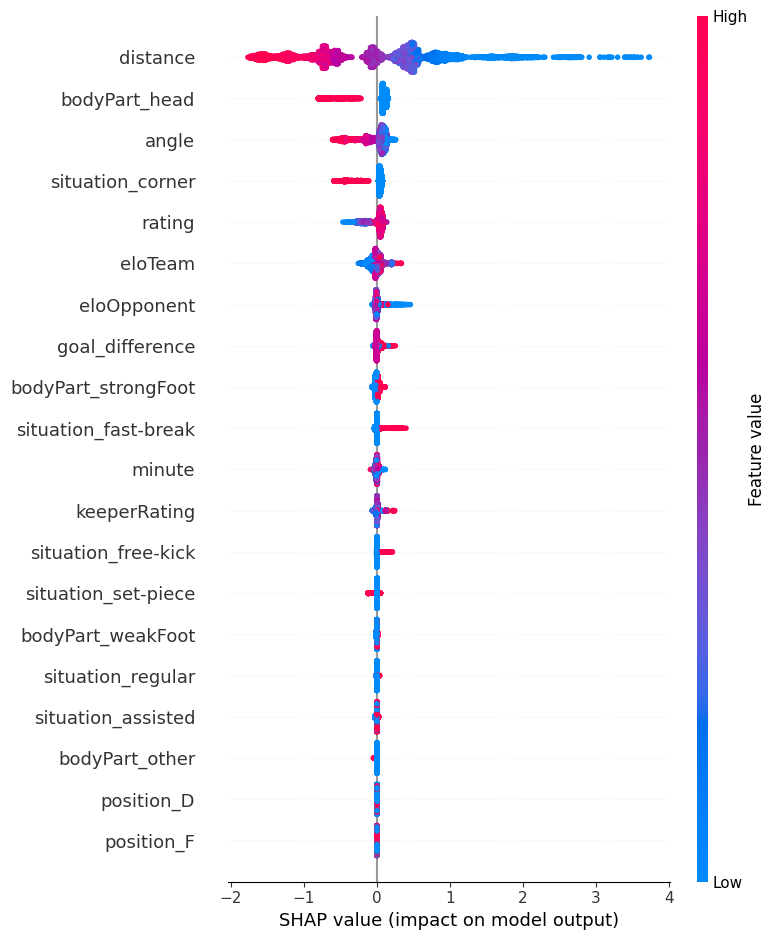

In [43]:
import shap
# import joblib
# model = joblib.load('models/ITA_2425.sav')
df = pd.read_csv('datasets/sofascore/seriea_2425.csv')
df = df.drop(columns=['Unnamed: 0'])
model, X_train, metrics = getPredictions(df)
explainer = shap.Explainer(model, X_train)
shapValues = explainer(X_train)
shap.summary_plot(shapValues, X_train)
# shap.plots.bar(shapValues)

In [ ]:
tournamentId = 23 # serie a
# seasonId = 76457  # serie a 25/26
seasonId = 63515    # serie a 24/25
roundIndex = 38
# tournamentId = 17 # premier league
# seasonId = 76986  # premier league 25/26
options = Options()
options.set_preference("permissions.default.image", 2)

driver = webdriver.Firefox(options=options)


# for roundIndex in range(17,33):
lastTime = 0
# for roundIndex in range(4,39):
for gameIndex in range(7,10):
    driver.get("https://www.sofascore.com")
    # gameIndex = 0
    print(roundIndex, gameIndex)
    shotmap = getBaseShotmap(league="ITA-Serie A", tournamentId=tournamentId, seasonId=seasonId, roundIndex=roundIndex, gameIndex=gameIndex, debug=False, season=25, driver=driver, update='feb')
    shots = getShotsDF(shotmap)
    if roundIndex == 1 and gameIndex == 0:
        shots.to_csv('datasets/sofascore/seriea_2425_test.csv', header=True)
    else:
        shots.to_csv('datasets/sofascore/seriea_2425_test.csv', mode='a', header=False)
    clear_output(wait=True)
driver.quit()
# 16 8

In [ ]:
tournamentId = 23 # serie a
# seasonId = 76457  # serie a 25/26
seasonId = 63515    # serie a 24/25
# tournamentId = 17 # premier league
# seasonId = 76986  # premier league 25/26
roundIndex = 1
gameIndex = 1

options = Options()
options.set_preference("permissions.default.image", 2)
driver = webdriver.Firefox(options=options)
driver.get("https://www.sofascore.com")


shotmap = getBaseShotmap(league="ITA-Serie A", tournamentId=tournamentId, seasonId=seasonId, roundIndex=roundIndex, gameIndex=gameIndex, debug=True, season=25, driver=driver, update='sep')
shots = getShotsDF(shotmap)
shots.to_csv('datasets/sofascore/seriea_2425_test.csv', mode='a', header=False)


In [ ]:
tournamentId = 23
seasonId = 76457
# roundIndex = 1

for roundIndex in range(33,36):
    for gameIndex in range(0,10):
        # gameIndex = 0
        shotmap = getBaseShotmap(league="ITA-Serie A", tournamentId=tournamentId, seasonId=seasonId, roundIndex=roundIndex, gameIndex=gameIndex, debug=False, season=26)
        shots = getShotsDF(shotmap)
        if roundIndex == 1 and gameIndex == 0:
            shots.to_csv('datasets/sofascore/seriea_2526_test.csv', header=True)
        else:
            shots.to_csv('datasets/sofascore/seriea_2526_test.csv', mode='a', header=False)

In [ ]:
schedule = pd.read_csv('schedules/seriea.csv')
schedule = schedule.drop(columns='Unnamed: 0')
gameIndex = 0
game = schedule.loc[gameIndex]
shotmap = getBaseShotmap(game=game, index=gameIndex, versions=versions, league='ITA-Serie A', filename='seriea_2526', debug=False)
# shotmap = getShotsDF(shotmap)
# shotmap.to_csv('datasets/sofascore/seriea_2526.csv')
# schedule

In [ ]:
for i in range(1,330):
    gameIndex = i
    game = schedule.loc[gameIndex]
    shotmap = getBaseShotmap(game=game, index=gameIndex, versions=versions, league='ITA-Serie A', filename='seriea_2526', debug=False)
    shotmap = getShotsDF(shotmap)
    clear_output(wait=True)
    shotmap.to_csv('datasets/sofascore/seriea_2526.csv', mode='a', header=False)

In [ ]:
getShotsDF(shotmap).loc[0]

In [ ]:
# fixtures storage

# seriea:   23  76457
# premier:  17  76986
# liga:     8   77559
# bundes:   35  77333
# ligue1:   34  77356

leagueId = 23
seasonId = 76457
# seasonId = 63515    # serie a 24/25

league = "seriea"

options = Options()
options.set_preference("permissions.default.image", 2)
driver = webdriver.Firefox(options=options)
driver.get("https://www.sofascore.com")

roundSchedule = getSchedule(leagueId=leagueId, seasonId=seasonId, round=1, driver=driver)
roundSchedule.to_csv('schedules/' + str(league) + '.csv', header=True)
for i in range(34, 39):
    roundSchedule = getSchedule(leagueId=leagueId, seasonId=seasonId, round=i, driver=driver)
    roundSchedule.to_csv('schedules/' + str(league) + '.csv', mode='a', header=False)

In [ ]:
driver = webdriver.Firefox()
url = 'https://sofifa.com/player/273915'
driver.get(url)
driver.quit()

In [ ]:
from selenium import webdriver
from selenium.webdriver.firefox.options import Options

options = Options()
options.headless = True  # niente GUI

driver = webdriver.Firefox(options=options)
driver.get("https://sofifa.com/player/273915")
driver.quit()

In [ ]:
import pandas as pd
df = pd.read_csv('datasets/sofascore/seriea_2526_test.csv')
df = df.drop(columns=['Unnamed: 0'])
df

In [ ]:
import pandas as pd
import math
df = pd.read_csv('datasets/sofascore/seriea_2526.csv')
distances = []
angles = []
for i in df.index:
    x = df.loc[i]['x']
    y = df.loc[i]['y']
    distance, angle = convertXY(x, y)
    distances.append(distance)
    angles.append(angle)
df['distance'] = distances
df['angle'] = angles
df.to_csv('datasets/sofascore/seriea_2526.csv')

In [ ]:
year = 24
league = 'ita'
season = 2324
sepUpdate = 240002
febUpdate = 240027
teamIndex = 0
version = febUpdate

teamsDF = pd.read_csv('utility/leaguesteams.csv')
teams = teamsDF.loc[(teamsDF['league'] == league) & (teamsDF['season'] == season)][['team', 'teamId']].reset_index()
for teamIndex in range(0,20):
# teamIndex = 11
    teamName = teams.loc[teamIndex]['team']
    teamId = teams.loc[teamIndex]['teamId']
    playersDF = readPlayersSelenium(teamId=teamId, version=version)
    playersDF['version'] = version
    playersDF['team'] = teamName
    playersDF['teamId'] = teamId
    playersDF = playersDF[['team', 'teamId', 'player', 'playerId', 'version']]
    playersDF.to_csv('utility/teamPlayers.csv', mode='a', header=False)

In [ ]:
league = 'ita'
season = 2324
sepUpdate = 240002
febUpdate = 240027

teamsDF = pd.read_csv('utility/leaguesteams.csv')
teams = teamsDF.loc[(teamsDF['league'] == league) & (teamsDF['season'] == season)][['team', 'teamId']].reset_index()
teamIndex = 10
teamName = teams.loc[teamIndex]['team']
teamId = teams.loc[teamIndex]['teamId']
playersDF = readPlayersSelenium(teamId=teamId, version=sepUpdate)
playersDF    

In [ ]:
session = getSession()
for i in range(0,29):
    player = playersDF.loc[[i]]
    playerId = player['playerId'].iloc[0]
    playerName = player['player'].iloc[0]
    getShootingRatingCloud(playerId=playerId, versionId=sepUpdate, season=24, update='sep', teamId=teamId, teamName=teamName, playerName=playerName, session=session)
    # getOverallRatingCloud(playerId=playerId, versionId=sepUpdate, season=24, update='sep', teamId=teamId, teamName=teamName, playerName=playerName, session=session)

In [ ]:
tournamentId = 23 # serie a
seasonId = 76457  # serie a 25/26
# seasonId = 63515    # serie a 24/25

week = 1
standings_df = standings_data(tournament_id=tournamentId, season_id=seasonId, data_source="sofavpn")

for week in range(1,39):
    match_df = match_data(tournament_id=tournamentId, season_id=seasonId, week_number=week, data_source="sofavpn")

    matchDates = []

    for i in match_df.index:
        matchTime = match_df.loc[i]['start_timestamp']
        matchDate = datetime.fromtimestamp(matchTime)
        matchDate = matchDate.strftime(("%d/%m/%Y"))
        matchDates.append(matchDate)

    new_df = pd.DataFrame()
    new_df['date'] = matchDates
    new_df['home_team'] = match_df['home_team']
    new_df['away_team'] = match_df['away_team']
    new_df['home_score'] = match_df['home_score_current']
    new_df['away_score'] = match_df['away_score_current']
    new_df['season'] = 26
    new_df['round'] = week
    new_df = new_df[['season', 'round', 'date', 'home_team', 'away_team', 'home_score', 'away_score']]

    if week == 1:
        new_df.to_csv('schedules/seriea.csv', header=True)
    else:
        new_df.to_csv('schedules/seriea.csv', header=False, mode='a')

    # new_df.to_csv('schedules/seriea.csv', header=False, mode='a')

# for week in range(1,39):
#     standings_df = standings_data(tournament_id=tournamentId, season_id=seasonId, data_source="sofavpn")
#     match_df = match_data(tournament_id=tournamentId, season_id=seasonId, week_number=week, data_source="sofavpn")
#     print(week, len(match_df))

In [ ]:
tournamentId = 23 # serie a
seasonId = 76457  # serie a 25/26
# seasonId = 63515    # serie a 24/25

search_data("seriea", entity_type="tournament", data_source="sofavpn")

In [40]:
df = pd.read_csv('datasets/sofascore/seriea_2425.csv')
model, X_train, metrics = getPredictions(df)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Precision: 0.84615
Recall: 0.06587
Accuracy: 0.91319
F1: 0.12222
AUC: 0.79938
Log Loss: 0.25585
Brier: 0.07226
MAE: 0.14792


In [41]:
stats = predictGame(model=model, trainDF='seriea_2425_test', testDF='seriea_2526_test', league="ITA-Serie A", tournamentId=23, seasonId=76457, roundIndex=1, gameIndex=1, local=True)
stats['homeShots']['xg'] = round(stats['homeShots']['xg'], 2)
stats['homeShots']['xgPred'] = round(stats['homeShots']['xgPred'], 2)
stats['homeShots']['diff'] = round(stats['homeShots']['diff'], 2)
stats['awayShots']['xg'] = round(stats['awayShots']['xg'], 2)
stats['awayShots']['xgPred'] = round(stats['awayShots']['xgPred'], 2)
stats['awayShots']['diff'] = round(stats['awayShots']['diff'], 2)

stats['homeShots_clean'] = stats['homeShots_clean'].reset_index()
stats['homeShots_clean'] = stats['homeShots_clean'].drop(columns=['index'])
# shot = stats['homeShots_clean'].loc[2]
# explainer = shap.Explainer(model, X_train)
# shapValues = explainer(shot)
# shap.plots.bar(shapValues)

DataNotAvailableError: No standings data found for tournament_id=23, season_id=76457.

In [2]:
import pandas as pd
import numpy as np
testDF = pd.read_csv('datasets/sofascore/seriea_2526.csv')
testDF = testDF.drop(columns=['Unnamed: 0'])
allShotsDF = pd.read_excel('allShots/allShots_ITA_2425.xlsx')
allShotsDF = allShotsDF.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
# allShotsDF.to_csv('datasets/sofascore/allShots/allShots_test.csv')
allShotsDF
# np.unique(allShotsDF['keeper'])
# keeperIDs = []
# for i in allShotsDF.index:
#     shot = allShotsDF.loc[i]
#     keeper = shot['keeper']
#     playerID = testDF.loc[testDF['keeper'] == keeper].reset_index().loc[0]['keeperId']
#     keeperIDs.append(playerID)
# allShotsDF['keeperID'] = keeperIDs
# allShotsDF.to_excel('allShots/allShots_ITA_2425.xlsx')

,game_index,home_team,away_team,minute,goal,goalPred,xg,xgPred,diff,goal_difference,...,eloOpponent,isHome,x,y,distance,angle,situation,body_part,playerID,keeperID
0,7,AC Milan,AS Roma,1,0,0,0.058612,0.142847,0.084235,0,...,1803,False,15.6,50.3,15,0,assisted,strongFoot,186855,191210
1,7,AC Milan,AS Roma,7,0,0,0.033866,0.149384,0.115517,0,...,1803,False,24.4,53.6,24,5,regular,strongFoot,1128530,191210
2,7,AC Milan,AS Roma,10,0,0,0.075174,0.038649,-0.036525,0,...,1803,False,8.5,48.7,8,5,set-piece,head,848287,191210
3,7,AC Milan,AS Roma,15,0,0,0.021357,0.108115,0.086758,0,...,1803,False,8.0,30.9,15,58,assisted,weakFoot,1134200,191210
4,7,AC Milan,AS Roma,17,0,0,0.171078,0.068878,-0.102200,0,...,1803,False,13.0,40.7,14,25,fast-break,strongFoot,256219,191210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6759,6,Udinese,SSC Napoli,78,0,0,0.041791,0.098797,0.057006,-1,...,1624,False,18.3,49.5,18,1,assisted,weakFoot,879346,891656
6760,6,Udinese,SSC Napoli,88,0,0,0.562607,0.401444,-0.161163,-1,...,1624,False,4.3,47.6,4,20,assisted,weakFoot,1086417,891656
6761,6,Udinese,SSC Napoli,90,0,0,0.110900,0.166776,0.055877,1,...,1832,True,10.1,51.9,10,7,regular,strongFoot,1009661,356160
6762,6,Udinese,SSC Napoli,90,0,0,0.465838,0.115027,-0.350811,-1,...,1624,False,5.3,62.5,10,58,assisted,strongFoot,962364,891656
